# **Version 12 개선 방향**

모델 구조 변경
- 연속형 특징 및 범주형 특징 브랜치를 FT-Transformer 사용

# **데이터 로드 및 증강**

In [ ]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow-addons

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 29.0 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.4
    Uninstalling typeguard-4.4.4:
      Successfully uninstalled typeguard-4.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [ ]:
# 모델 분석 및 시각화 도구
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import xml.etree.ElementTree as ET
from PIL import Image
from collections import Counter
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.metrics import structural_similarity as ssim

# Scikit-learn (데이터 전처리 및 모델 평가)
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, LabelBinarizer

# 모델 설계
import tensorflow as tf
from tensorflow.keras.losses import CategoricalFocalCrossentropy

# 모델 구조 및 레이어
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Dense, Conv2D, MaxPooling2D,
Flatten, Dropout, BatchNormalization, Embedding,
LeakyReLU, GlobalAveragePooling2D, concatenate, LayerNormalization, MultiHeadAttention, Reshape)
from tensorflow.keras.layers import Lambda, Add, Activation, Multiply

# 사전 훈련된 모델
from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV2, MobileNetV3Small, VGG16, InceptionV3, Xception, DenseNet121

# 컴파일 및 훈련 관련
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical


In [ ]:
from skimage.metrics import structural_similarity as ssim

# 좌표 연속형 10특징 반환 함수
def build_cont_features(xc, yc, bw, bh, wafer_cx, wafer_cy, wafer_r_norm, eps=1e-6):

    # 웨이퍼 중심 기준 좌표
    dx = xc - wafer_cx
    dy = yc - wafer_cy

    # 반경 정규화(0~1)
    dist_norm = np.sqrt(dx*dx + dy*dy)    # 좌표 간 거리
    r_norm = np.clip(dist_norm / max(wafer_r_norm, eps), 0.0, 1.0)    # 정규화

    # 각도(라디안) 및 sin/cos
    theta = np.arctan2(dy, dx)    # 각도
    sin_th = np.sin(theta)
    cos_th = np.cos(theta)

    # 파생특징
    area_norm   = bw * bh                           # 결함의 상대적 크기
    aspect_log  = np.log((bw + eps) / (bh + eps))   # 결함의 종횡비
    edge_margin = 1.0 - r_norm                      # 결함과 가장자리간 거리

    # 중심좌표를 [-1,1] 범위로 스케일(반지름 기준)
    x_centered = np.clip((dx / max(wafer_r_norm, eps)), -1.5, 1.5)
    y_centered = np.clip((dy / max(wafer_r_norm, eps)), -1.5, 1.5)

    # 연속형 특징 저장
    cont = np.array([
        x_centered, y_centered, bw, bh,
        r_norm, sin_th, cos_th, area_norm,
        aspect_log, edge_margin
    ], dtype=np.float32)

    # 출력
    return cont, r_norm, theta

# 좌표값 검증 함수
def validate_coordinates(xc, yc, bw, bh):
    xc = np.clip(xc, 0.0, 1.0)
    yc = np.clip(yc, 0.0, 1.0)
    bw = np.clip(bw, 1e-6, 1.0) # 너비가 0이 되지 않도록
    bh = np.clip(bh, 1e-6, 1.0) # 높이가 0이 되지 않도록
    return xc, yc, bw, bh

# 증강 이미지 품질 검증 함수
def validate_augmentation(original_img, augmented_img, min_ssim=0.7):

    # 이미지를 흑백으로 변환하여 구조적 유사도만 비교
    orig_gray = cv2.cvtColor(original_img, cv2.COLOR_RGB2GRAY)
    aug_gray = cv2.cvtColor(augmented_img, cv2.COLOR_RGB2GRAY)

    # 원본 이미지가 uint8 (0~255)이므로, data_range를 255 설정
    score, _ = ssim(orig_gray, aug_gray, full=True, data_range=255)

    # 점수가 기준치 이상이면 유효한 증강으로 판단
    return score >= min_ssim


def load_original_data_with_base(csv_path, image_root, image_size, fallback_bins=(8,16)):

    # CSV 파일 불러오기
    df = pd.read_csv(csv_path)

    # 정보 저장
    info = ['class','cropped_image','x_center_norm','y_center_norm','width_norm','height_norm']

    # 오류 검증
    for c in info:
        if c not in df.columns:
            raise ValueError(f"CSV에 '{c}' 컬럼이 필요합니다.")

    # 웨이퍼 중심 좌표 저장
    has_wafer = all(c in df.columns for c in ['wafer_cx_norm','wafer_cy_norm','wafer_r_norm'])

    # 리스트 생성
    images, cont_list, rad_bins, sec_bins, labels = [], [], [], [], []

    # 좌표 정보 리스트 생성
    base_coords = []  # (xc, yc, bw, bh, wafer_cx, wafer_cy, wafer_r_norm)


    N_RAD, N_SEC = fallback_bins

    # 결함 패턴에 대한 정보 수집
    for _, row in tqdm(df.iterrows(), total=df.shape[0]):
        img_path = os.path.join(image_root, row['class'], row['cropped_image'])
        img = cv2.imread(img_path)
        if img is None:
            print(f"경고: 이미지를 로드할 수 없습니다 - {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, image_size)

        xc = float(row['x_center_norm'])    # 바운딩 박스 중심 x 좌표
        yc = float(row['y_center_norm'])    # 바운딩 박스 중심 y 좌표
        bw = float(row['width_norm'])       # 바운딩 박스 밑변
        bh = float(row['height_norm'])      # 바운딩 박스 높이
        wafer_cx = float(row['wafer_cx_norm']) if has_wafer else 0.5    # 웨이퍼 중심 x 좌표
        wafer_cy = float(row['wafer_cy_norm']) if has_wafer else 0.5    # 웨이퍼 중심 y 좌표
        wafer_rn = float(row['wafer_r_norm'])  if has_wafer else 0.5    # 웨이퍼의 반지름

        # 7개의 좌표를 바탕으로 연속형 특징 추출
        cont, r_norm, theta = build_cont_features(xc,yc,bw,bh, wafer_cx,wafer_cy,wafer_rn)

        # 범주형 특징 추출
        if 'rad_bin' in df.columns and 'sec_bin' in df.columns:
            rad_bin = int(row['rad_bin']); sec_bin = int(row['sec_bin'])
        else:
            rad_bin = int(np.clip(np.floor(r_norm * N_RAD), 0, N_RAD-1))
            two_pi = 2*np.pi
            sec_bin = int(np.floor(((theta % two_pi)/two_pi) * N_SEC))

        # 리스트에 저장
        images.append(img)
        cont_list.append(cont)
        rad_bins.append(rad_bin)
        sec_bins.append(sec_bin)
        labels.append(row['class'])
        base_coords.append([xc,yc,bw,bh, wafer_cx,wafer_cy,wafer_rn])

    print(f"-> 원본 데이터 로딩 완료: {len(images)}개 샘플")
    return (np.asarray(images, dtype=np.float32),
            np.asarray(cont_list, dtype=np.float32),
            np.asarray(rad_bins, dtype=np.int32),
            np.asarray(sec_bins, dtype=np.int32),
            np.asarray(labels),
            np.asarray(base_coords, dtype=np.float32))

# 연속형 특징 재계산 함수 ( 증강된 이미지에 대한 좌표 재계산)
def _recompute_cont_from_base(xc, yc, bw, bh, wafer_cx, wafer_cy, wafer_rn):
    cont, r_norm, theta = build_cont_features(xc,yc,bw,bh, wafer_cx,wafer_cy,wafer_rn)
    two_pi = 2*np.pi
    rad_bin = int(np.clip(np.floor(r_norm * 8), 0, 7))
    sec_bin = int(np.floor(((theta % two_pi)/two_pi) * 16))
    return cont, rad_bin, sec_bin


# 데이터 증강 함수
def augment_and_balance_data(
    images, cont_features, rad_bins, sec_bins, labels, base_coords,
    augment_params: dict,
    random_state=42
):
    labels_series = pd.Series(labels)
    class_counts = labels_series.value_counts()
    target_count = class_counts.max()
    print(f"-> 데이터 증강 목표 개수 (각 클래스별): {target_count}")

    # 최종 데이터를 담을 리스트 (원본 데이터로 초기화)
    X_img, X_cont, X_rbin, X_sbin, y = \
        list(images), list(cont_features), list(rad_bins), list(sec_bins), list(labels)

    for cls, count in class_counts.items():
        if count >= target_count:
            continue

        needed = target_count - count
        original_indices = np.where(labels == cls)[0]
        print(f"클래스 '{cls}': {needed}개 증강 시작")

        augmented_count = 0
        while augmented_count < needed:
            idx = np.random.choice(original_indices)

            # 증강의 기반이 될 원본 데이터 선택
            original_image_for_aug = images[idx].copy()
            xc, yc, bw, bh, wcx, wcy, wrn = base_coords[idx]

            # 증강 작업을 수행할 이미지 변수 (원본 복사본으로 시작)
            augmented_img = original_image_for_aug.copy()

            # --- 좌우 반전 ---
            if np.random.rand() < augment_params.get('p_hflip', 0.0):
                augmented_img = np.flip(augmented_img, axis=1) # ⭐ augmented_img 사용
                xc = 1.0 - xc

            # --- 상하 반전 ---
            if np.random.rand() < augment_params.get('p_vflip', 0.0):
                augmented_img = np.flip(augmented_img, axis=0) # ⭐ augmented_img 사용
                yc = 1.0 - yc

            # --- 회전 ---
            if np.random.rand() < augment_params.get('p_rotate', 0.0):
                limit = augment_params.get('rotate_limit', 15)
                angle = np.random.uniform(-limit, limit)
                h, w = augmented_img.shape[:2] # ⭐ augmented_img 사용
                M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
                augmented_img = cv2.warpAffine(augmented_img, M, (w, h)) # ⭐ augmented_img 사용

                angle_rad = np.radians(angle)
                x_shifted, y_shifted = xc - 0.5, yc - 0.5
                xc_new = x_shifted * np.cos(angle_rad) - y_shifted * np.sin(angle_rad)
                yc_new = x_shifted * np.sin(angle_rad) + y_shifted * np.cos(angle_rad)
                xc, yc = xc_new + 0.5, yc_new + 0.5

            # 증강된 좌표 유효성 검증
            xc, yc, bw, bh = validate_coordinates(xc, yc, bw, bh)

            # --- 밝기/대비 조절 ---
            if np.random.rand() < augment_params.get('p_brightness_contrast', 0.0):
                alpha = 1.0 + np.random.uniform(-0.2, 0.2)
                beta = 10 * np.random.uniform(-1, 1)
                # augmented_img에 적용하고 uint8로 변환
                augmented_img = np.clip(alpha * augmented_img.astype(np.float32) + beta, 0, 255).astype(np.uint8)

            # 증강된 이미지 품질 검증
            if not validate_augmentation(original_image_for_aug, augmented_img):
                continue

            # 변경된 좌표로 모든 파생 특징 재계산
            new_cont, new_rbin, new_sbin = _recompute_cont_from_base(xc, yc, bw, bh, wcx, wcy, wrn)

            # 증강된 데이터를 리스트에 추가
            X_img.append(augmented_img)
            X_cont.append(new_cont)
            X_rbin.append(new_rbin)
            X_sbin.append(new_sbin)
            y.append(cls)

            # 유효한 증강 샘플 카운트 증가
            augmented_count += 1

        print(f"-> 클래스 '{cls}' 증강 완료 (총 {target_count}개)\n")

    # 6. 최종 데이터를 NumPy 배열로 변환하고 섞기
    X_img, X_cont, X_rbin, X_sbin, y = shuffle(
        np.asarray(X_img, dtype=np.uint8),  # 이미지는 uint8로 변환 후 shuffle
        np.asarray(X_cont, dtype=np.float32),
        np.asarray(X_rbin, dtype=np.int32),
        np.asarray(X_sbin, dtype=np.int32),
        np.asarray(y),
        random_state=random_state
    )

    return X_img, X_cont, X_rbin, X_sbin, y


In [ ]:
dataset_path = "/content/drive/MyDrive/ACK2025_Wafer/YOLO/Defect_Pattern_CNN_Dataset"
zip_file_name = "Pattern_Image_Coordinated_Dataset_v5.zip"
unzipped_dataset_path = "Pattern_Image_Coordinated_Dataset_v5"

# Colab 로컬로 데이터셋 이동 및 복사
print("데이터셋을 Colab 로컬 환경으로 복사합니다...")

# 변수를 사용하여 파일 경로를 동적으로 생성
zip_file_path_in_drive = os.path.join(dataset_path, zip_file_name)
!cp "{zip_file_path_in_drive}" /content/
print("압축 해제를 시작합니다...")
!unzip -o -q /content/"{zip_file_name}" -d /content/
print("데이터셋 준비 완료.")

# 로컬 폴더 목록 확인
print("\n/content/ 폴더 내용 확인:")
!ls -l /content/

데이터셋을 Colab 로컬 환경으로 복사합니다...
압축 해제를 시작합니다...
데이터셋 준비 완료.

/content/ 폴더 내용 확인:
total 159424
drwx------  6 root root      4096 Aug  9 14:08 drive
drwxrwxrwx 10 root root      4096 Aug  8 10:43 Pattern_Image_Coordinated_Dataset_v5
-rw-------  1 root root 163229845 Aug  9 14:09 Pattern_Image_Coordinated_Dataset_v5.zip
drwxr-xr-x  1 root root      4096 Aug  7 13:42 sample_data


In [ ]:

# 데이터셋 경로 설정 및 이미지 크기 조절
csv_path = os.path.join(dataset_path, "bbox_info_v5.csv")
image_root = os.path.join("/content/", unzipped_dataset_path)
image_size = (128, 128)

# 데이터 로드
images, cont_features, rad_bins, sec_bins, labels, base_coords = load_original_data_with_base(csv_path, image_root, image_size)

# 적용할 데이터 증강 기법과 확률을 딕셔너리로 정의
augment_parameters = {
  'p_hflip': 0.5,
  'p_vflip': 0.5,
  'p_rotate': 0.3,
  'rotate_limit': 20, # -20 ~ +20도 사이에서 회전
  'p_brightness_contrast': 0.4
}

# 증강 함수 호출
X_aug_img, X_aug_cont, X_aug_rbin, X_aug_sbin, y_aug = augment_and_balance_data(
images, cont_features, rad_bins, sec_bins, labels, base_coords, augment_params=augment_parameters)

X_train_final = {
    'image': X_aug_img,
    'continuous': X_aug_cont,
    'radial_bin': X_aug_rbin,
    'sector_bin': X_aug_sbin
}
y_train_final = y_aug

100%|██████████| 6255/6255 [00:16<00:00, 374.78it/s]


-> 원본 데이터 로딩 완료: 6255개 샘플
-> 데이터 증강 목표 개수 (각 클래스별): 1004
클래스 'Edge-Ring': 25개 증강 시작
-> 클래스 'Edge-Ring' 증강 완료 (총 1004개)

클래스 'Loc': 56개 증강 시작
-> 클래스 'Loc' 증강 완료 (총 1004개)

클래스 'Center': 71개 증강 시작
-> 클래스 'Center' 증강 완료 (총 1004개)

클래스 'Random': 150개 증강 시작
-> 클래스 'Random' 증강 완료 (총 1004개)

클래스 'Edge-Loc': 151개 증강 시작
-> 클래스 'Edge-Loc' 증강 완료 (총 1004개)

클래스 'Donut': 470개 증강 시작
-> 클래스 'Donut' 증강 완료 (총 1004개)

클래스 'Near-full': 854개 증강 시작
-> 클래스 'Near-full' 증강 완료 (총 1004개)



In [ ]:
# --- 사전 준비: 라벨 데이터를 모델 학습에 맞게 변환 ---
# 1. 문자 라벨 -> 정수 라벨로 변환 (stratify에 사용)
encoder = LabelEncoder()
y_integer_labels = encoder.fit_transform(y_train_final)

# 2. 정수 라벨 -> 원-핫 인코딩 (모델의 최종 출력과 비교할 때 사용)
# 예: 3개의 클래스가 있다면 [0, 1, 2] -> [[1,0,0], [0,1,0], [0,0,1]]
y_categorical_labels = to_categorical(y_integer_labels)


# --- 데이터 분리 (Train/Test Split) ---
# 1. 분리할 모든 입력 데이터와 라벨을 함수에 전달합니다.
X_img_train, X_img_test, \
X_cont_train, X_cont_test, \
X_rbin_train, X_rbin_test, \
X_sbin_train, X_sbin_test, \
y_train, y_test = train_test_split(
    X_train_final['image'],
    X_train_final['continuous'],
    X_train_final['radial_bin'],
    X_train_final['sector_bin'],
    y_categorical_labels,  # 분리할 라벨 데이터 (원-핫 인코딩된 형태)
    test_size=0.2,
    random_state=42,
    stratify=y_integer_labels  # ★분포 유지를 위해서는 정수 라벨을 사용
)

# 2. 분리된 데이터를 다시 딕셔너리로 묶어주면 관리가 편합니다.
X_train = {
    'image': X_img_train,
    'continuous': X_cont_train,
    'radial_bin': X_rbin_train,
    'sector_bin': X_sbin_train
}

X_test = {
    'image': X_img_test,
    'continuous': X_cont_test,
    'radial_bin': X_rbin_test,
    'sector_bin': X_sbin_test
}


# --- 분리 결과 확인 ---
print("✅ 데이터 분리 완료!")
print(f"훈련 데이터 개수: {len(X_train['image'])}")
print(f"테스트 데이터 개수: {len(X_test['image'])}")

# 클래스 분포 확인
print("\n훈련 데이터셋의 클래스 분포:")
y_train_int_labels = np.argmax(y_train, axis=1)
print(pd.Series(encoder.inverse_transform(y_train_int_labels)).value_counts())

print("\n테스트 데이터셋의 클래스 분포:")
y_test_int_labels = np.argmax(y_test, axis=1)
print(pd.Series(encoder.inverse_transform(y_test_int_labels)).value_counts())

✅ 데이터 분리 완료!
훈련 데이터 개수: 6425
테스트 데이터 개수: 1607

훈련 데이터셋의 클래스 분포:
Donut        804
Edge-Loc     803
Near-full    803
Loc          803
Center       803
Scratch      803
Edge-Ring    803
Random       803
Name: count, dtype: int64

테스트 데이터셋의 클래스 분포:
Edge-Ring    201
Edge-Loc     201
Near-full    201
Center       201
Loc          201
Scratch      201
Random       201
Donut        200
Name: count, dtype: int64


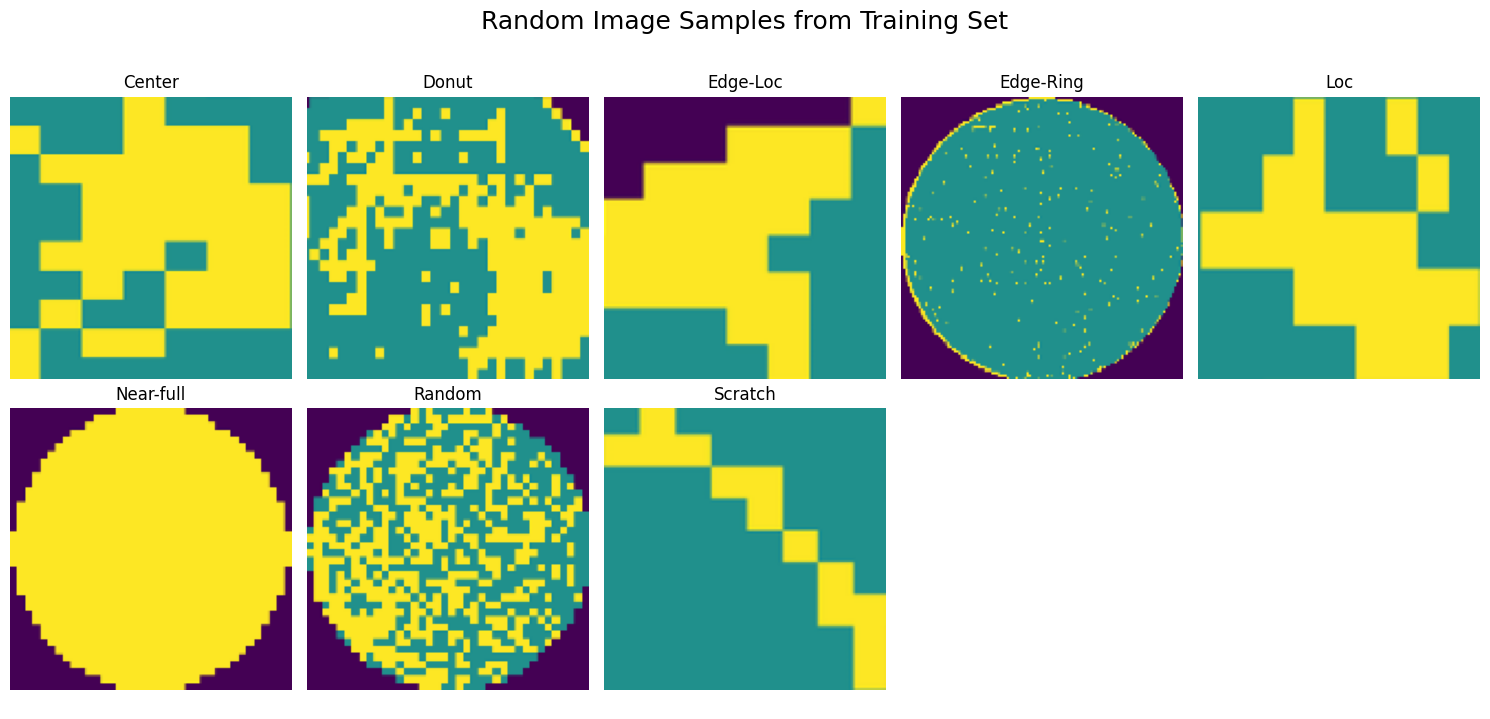

In [ ]:
# 1. 클래스 정보 가져오기
unique_classes = encoder.classes_
num_classes = len(unique_classes)

# 2. 이미지를 출력할 격자(Grid) 설정
cols = 5
# 클래스 개수에 맞춰 행(row) 수를 자동으로 계산합니다.
rows = math.ceil(num_classes / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
axes = axes.flatten() # 2D 배열을 1D로 만들어 쉽게 다룰 수 있게 함

# 3. 각 클래스별로 랜덤 이미지 출력
for i, class_name in enumerate(unique_classes):
    # 현재 클래스에 해당하는 정수 라벨 찾기
    class_code = encoder.transform([class_name])[0]

    # 훈련 세트에서 현재 클래스에 해당하는 모든 이미지의 인덱스를 찾습니다.
    indices_for_class = np.where(y_train_int_labels == class_code)[0]
    # 그 인덱스들 중에서 하나를 무작위로 선택합니다.
    random_index = np.random.choice(indices_for_class)

    # 선택된 랜덤 인덱스로 이미지를 가져옵니다.
    sample_image = X_train['image'][random_index]

    # 격자의 해당 위치(ax)에 이미지와 제목을 표시
    ax = axes[i]
    # .astype('uint8')을 추가하여 이미지를 올바른 형식으로 표시
    ax.imshow(sample_image.astype('uint8'))
    ax.set_title(class_name, fontsize=12)
    ax.axis('off') # 축 번호 숨기기

# 4. 사용되지 않은 빈 격자 숨기기
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Random Image Samples from Training Set', fontsize=18, y=1.02)
plt.tight_layout() # 이미지들이 겹치지 않게 자동 조절
plt.show()

# **모델 학습**

In [ ]:
# 모델 학습 결과 시각화 함수
def plot_training_history(history, model_name):

  # 정확도 그래프
  plt.figure(figsize=(14, 5))
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title(f'{model_name} - Accuracy', fontsize=14)
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Accuracy', fontsize=12)
  plt.legend()
  plt.grid(True)

  # 손실 그래프
  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title(f'{model_name} - Loss', fontsize=14)
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Loss', fontsize=12)
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

# 혼동 행렬 시각화 함수
def plot_confusion_matrix(y_true, y_pred_probs, class_names, normalize=False, title='Confusion Matrix'):

  # 확률을 최종 클래스 예측(인덱스)으로 변환
  y_pred_classes = np.argmax(y_pred_probs, axis=1)
  y_true_classes = np.argmax(y_true, axis=1)

  # normalize 옵션 설정
  if normalize:
    # 'true': 실제 라벨(행)을 기준으로 정규화
    cm = confusion_matrix(y_true_classes, y_pred_classes, normalize='true')
    fmt = '.2f' # 소수점 둘째 자리까지 표시
  else:
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    fmt = 'd' # 정수로 표시

  # 혼동 행렬 시각화
  plt.figure(figsize=(9, 8))
  sns.heatmap(
    cm,
    annot=True,
    fmt=fmt, # [개선 2] 포맷 변경
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
  )

  plt.xlabel('Predicted Class', fontsize=12)
  plt.ylabel('Actual Class', fontsize=12)
  plt.title(title, fontsize=15)
  plt.show()


## **1. Multi-Input NN**

In [ ]:
# --- 모델 구성 ---

# 입력층 정의

image_input = Input(shape=(128, 128, 3), name='image')    # 이미지 입력
continuous_input = Input(shape=(10,), name='continuous')  # 좌표 정보 입력
rad_bin_input = Input(shape=(1,), name='radial_bin')    # 반경 정보 입력
sec_bin_input = Input(shape=(1,), name='sector_bin')    # 섹터 정보 입력

# 이미지 처리 브랜치 (Flatten -> Dense)
image_flatten = Flatten()(image_input)
image_features = Dense(128, activation='relu')(image_flatten)

embedding_dim = 32

# 연속형 특징을 (None, 1, 32) 형태로 변환
split_features = Lambda(lambda x: tf.split(x, num_or_size_splits=10, axis=1))(continuous_input)
continuous_embeddings = []
for i, feature_tensor in enumerate(split_features):
    embedding = Dense(embedding_dim, name=f'cont_embed_{i}')(feature_tensor)
    # Reshape으로 차원을 (None, 1, 32)로 맞춥니다.
    reshaped_embedding = Reshape((1, embedding_dim))(embedding)
    continuous_embeddings.append(reshaped_embedding)

# 범주형 특징 임베딩
rad_bin_embedding = Embedding(input_dim=8, output_dim=embedding_dim, name='rad_embed')(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=embedding_dim, name='sec_embed')(sec_bin_input)

# 모든 토큰(임베딩) 결합
all_tokens = concatenate(continuous_embeddings + [rad_bin_embedding, sec_bin_embedding], axis=1)

# Transformer Encoder Block
num_transformer_blocks = 3
num_heads = 4
ff_dim = 32

x_coords = all_tokens
for i in range(num_transformer_blocks):
    # ... (Transformer Block 코드는 기존과 동일) ...
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, name=f'attention_{i}')(x_coords, x_coords)
    attn_output = Dropout(0.1)(attn_output)
    x_coords = LayerNormalization(name=f'layernorm1_{i}')(x_coords + attn_output)
    ffn_output = Dense(ff_dim, activation="relu", name=f'ffn_dense1_{i}')(x_coords)
    ffn_output = Dense(embedding_dim, name=f'ffn_dense2_{i}')(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)
    x_coords = LayerNormalization(name=f'layernorm2_{i}')(x_coords + ffn_output)

# Transformer를 통과한 최종 좌표 특징
coords_features = Flatten()(x_coords)


# 브랜치 통합
combined = concatenate([image_features, coords_features])

# 최종 분류층
x1 = Dense(128, activation='relu')(combined)
x1 = Dropout(0.5)(x1) # 과적합 방지를 위한 드롭아웃
x1 = Dense(64, activation='relu')(x1)
output = Dense(num_classes, activation='softmax', name='output')(x1) # num_classes는 이전에 계산됨


# --- 최종 모델 생성 ---
model_simple_nn = Model(
inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
outputs=output
)

# 모델 구조 확인
model_simple_nn.summary()

# --- 모델 컴파일 ---
model_simple_nn.compile(
optimizer='adam',
loss=CategoricalFocalCrossentropy(), # Focal Loss로 변경
metrics=['accuracy']
)
# --- 모델 훈련 ---
history_simple_nn = model_simple_nn.fit(
  X_train, y_train,
  epochs=50,
  batch_size=32,
  validation_data=(X_test, y_test),
  callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ continuous          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ [(None, 1),       │          0 │ continuous[0][0]  │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1),    │            │                   │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1),    │            │                   │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1)]    │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_0        │ (None, 32)        │         64 │ lambda_4[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_1        │ (None, 32)        │         64 │ lambda_4[0][1]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_2        │ (None, 32)        │         64 │ lambda_4[0][2]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_3        │ (None, 32)        │         64 │ lambda_4[0][3]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_4        │ (None, 32)        │         64 │ lambda_4[0][4]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_5        │ (None, 32)        │         64 │ lambda_4[0][5]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_6        │ (None, 32)        │         64 │ lambda_4[0][6]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_7        │ (None, 32)        │         64 │ lambda_4[0][7]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_8        │ (None, 32)        │         64 │ lambda_4[0][8]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_9        │ (None, 32)        │         64 │ lambda_4[0][9]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ radial_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sector_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_10          │ (None, 1, 32)     │          0 │ cont_embed_0[0][… │
│ (Reshape)           │                   │            │                 

 Total params: 6,424,552 (24.51 MB)

 Trainable params: 6,424,552 (24.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - accuracy: 0.1273 - loss: 3.5162 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1286 - loss: 3.5099 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1203 - loss: 3.5447 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1214 - loss: 3.5403 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1141 - loss: 3.5698 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1233 - loss: 3.5326 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1222 - loss: 3.5366 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1170 - loss: 3.5581 - val_accuracy: 

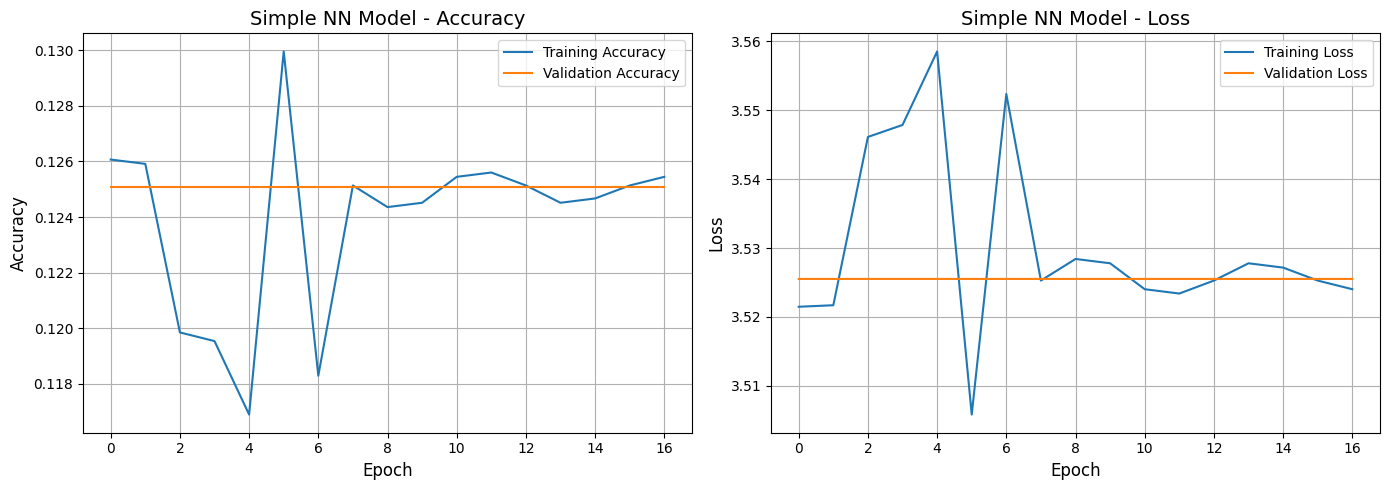

51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step


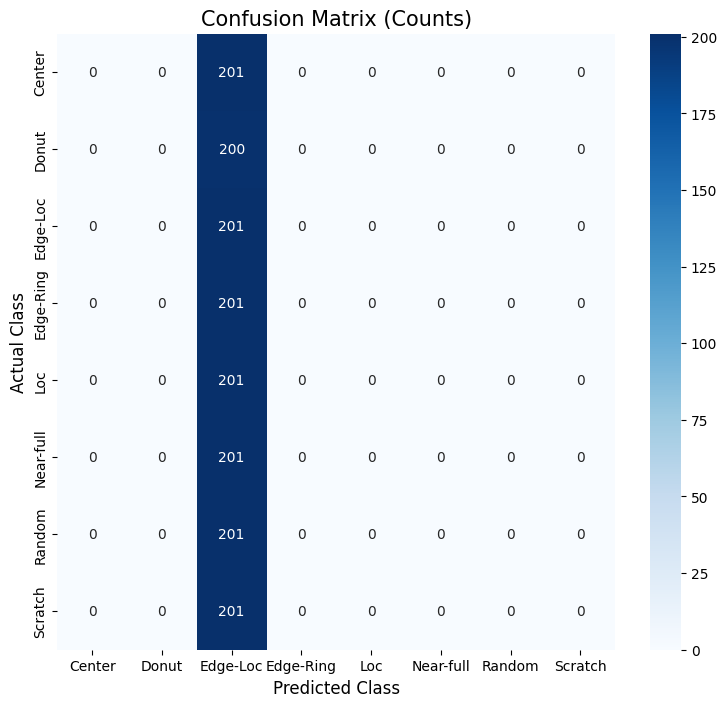

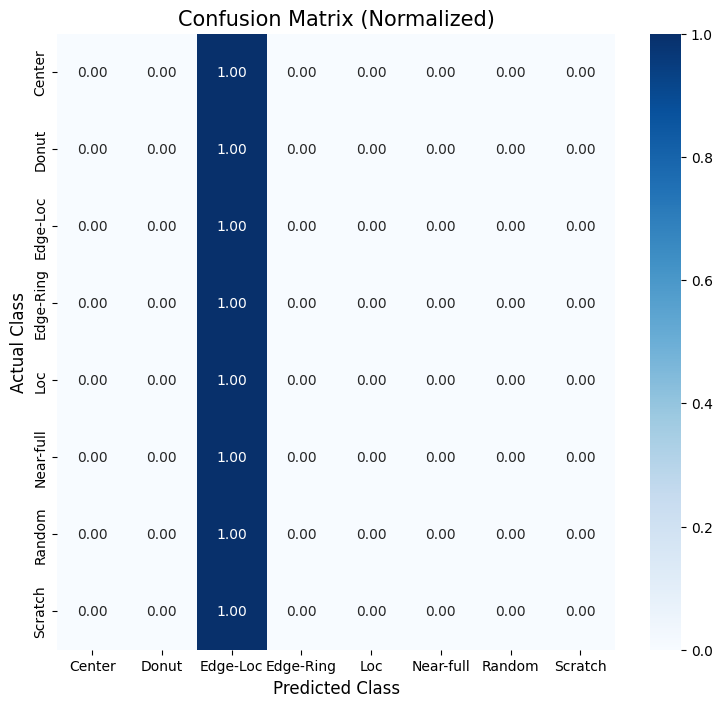

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_simple_nn, "Simple NN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_simple_nn.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **2. Multi-Input DNN**

In [ ]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image')
continuous_input = Input(shape=(10,), name='continuous')
rad_bin_input = Input(shape=(1,), name='radial_bin')
sec_bin_input = Input(shape=(1,), name='sector_bin')

# 이미지 처리 브랜치 (DNN)
image_flatten = Flatten()(image_input)
image_features = Dense(128, activation='relu')(image_flatten)
image_features = Dense(64, activation='relu')(image_features) # 레이어 추가

embedding_dim = 32

# 연속형 특징을 (None, 1, 32) 형태로 변환
split_features = Lambda(lambda x: tf.split(x, num_or_size_splits=10, axis=1))(continuous_input)
continuous_embeddings = []
for i, feature_tensor in enumerate(split_features):
    embedding = Dense(embedding_dim, name=f'cont_embed_{i}')(feature_tensor)
    # Reshape으로 차원을 (None, 1, 32)로 맞춥니다.
    reshaped_embedding = Reshape((1, embedding_dim))(embedding)
    continuous_embeddings.append(reshaped_embedding)

# 범주형 특징 임베딩
rad_bin_embedding = Embedding(input_dim=8, output_dim=embedding_dim, name='rad_embed')(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=embedding_dim, name='sec_embed')(sec_bin_input)

# 모든 토큰(임베딩) 결합
all_tokens = concatenate(continuous_embeddings + [rad_bin_embedding, sec_bin_embedding], axis=1)

# Transformer Encoder Block
num_transformer_blocks = 3
num_heads = 4
ff_dim = 32

x_coords = all_tokens
for i in range(num_transformer_blocks):
    # ... (Transformer Block 코드는 기존과 동일) ...
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, name=f'attention_{i}')(x_coords, x_coords)
    attn_output = Dropout(0.1)(attn_output)
    x_coords = LayerNormalization(name=f'layernorm1_{i}')(x_coords + attn_output)
    ffn_output = Dense(ff_dim, activation="relu", name=f'ffn_dense1_{i}')(x_coords)
    ffn_output = Dense(embedding_dim, name=f'ffn_dense2_{i}')(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)
    x_coords = LayerNormalization(name=f'layernorm2_{i}')(x_coords + ffn_output)

# Transformer를 통과한 최종 좌표 특징
coords_features = Flatten()(x_coords)


# 브랜치 통합
combined = concatenate([image_features, coords_features])

# 최종 분류층
x2 = Dense(128, activation='relu')(combined)
x2 = Dropout(0.5)(x2)
x2 = Dense(64, activation='relu')(x2)
output = Dense(num_classes, activation='softmax', name='output')(x2)

# --- 최종 모델 생성 ---
model_dnn = Model(
  inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
  outputs=output
)

# 모델 구조 확인
model_dnn.summary()

# --- 모델 컴파일 ---
model_dnn.compile(
  optimizer='adam',
  loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
  metrics=['accuracy']
)

# --- 모델 훈련 ---
history_dnn = model_dnn.fit(
  X_train, y_train,
  epochs=50,
  batch_size=32,
  validation_data=(X_test, y_test),
  callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ continuous          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ [(None, 1),       │          0 │ continuous[0][0]  │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1),    │            │                   │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1),    │            │                   │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1)]    │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_0        │ (None, 32)        │         64 │ lambda_5[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_1        │ (None, 32)        │         64 │ lambda_5[0][1]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_2        │ (None, 32)        │         64 │ lambda_5[0][2]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_3        │ (None, 32)        │         64 │ lambda_5[0][3]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_4        │ (None, 32)        │         64 │ lambda_5[0][4]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_5        │ (None, 32)        │         64 │ lambda_5[0][5]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_6        │ (None, 32)        │         64 │ lambda_5[0][6]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_7        │ (None, 32)        │         64 │ lambda_5[0][7]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_8        │ (None, 32)        │         64 │ lambda_5[0][8]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_9        │ (None, 32)        │         64 │ lambda_5[0][9]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ radial_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sector_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_20          │ (None, 1, 32)     │          0 │ cont_embed_0[0][… │
│ (Reshape)           │                   │            │                 

 Total params: 6,424,616 (24.51 MB)

 Trainable params: 6,424,616 (24.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.1246 - loss: 3.5231 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1258 - loss: 3.5225 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1277 - loss: 3.5151 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1331 - loss: 3.4932 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1303 - loss: 3.5043 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1277 - loss: 3.5148 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1298 - loss: 3.5063 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1234 - loss: 3.5323 - val_accuracy: 

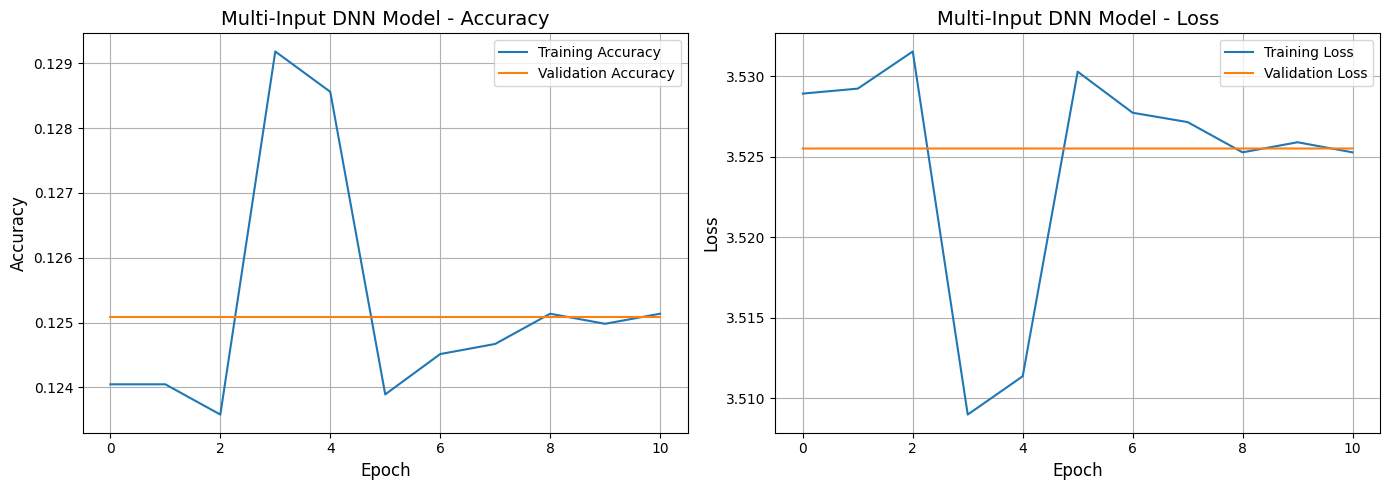

51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step


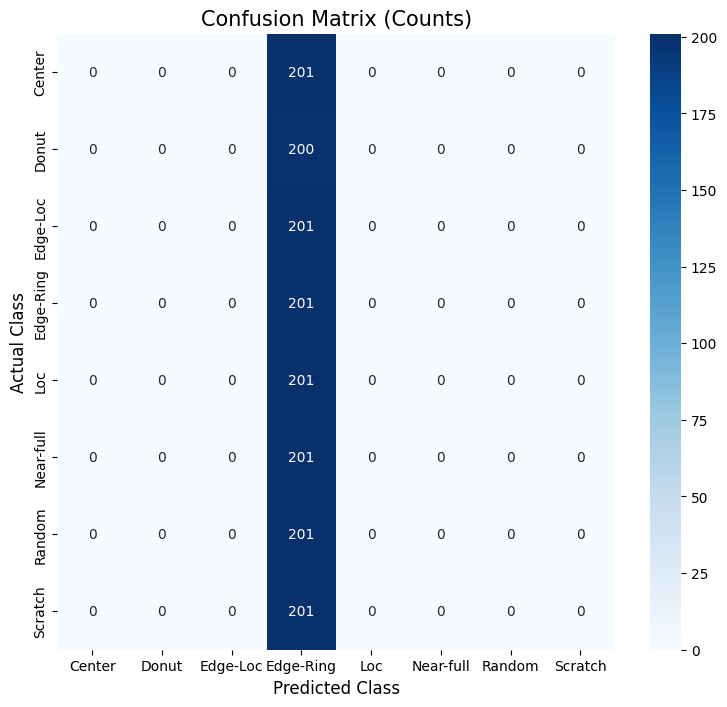

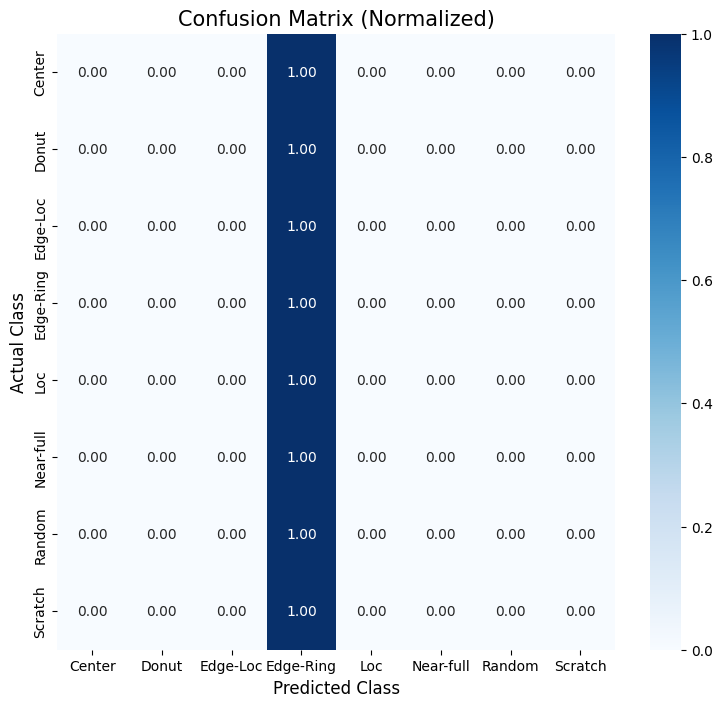

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_dnn, "Multi-Input DNN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_dnn.predict(X_test)

# 훈동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **3. Multi-Input ANN**

In [ ]:
# --- 모델 구성 ---

# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')
continuous_input = Input(shape=(10,), name='continuous')
rad_bin_input = Input(shape=(1,), name='radial_bin')
sec_bin_input = Input(shape=(1,), name='sector_bin')



# 이미지 처리 브랜치
x_img = Flatten()(image_input)
x_img = Dense(256)(x_img)
x_img = LeakyReLU(alpha=0.2)(x_img)
x_img = Dropout(0.5)(x_img)
x_img = Dense(128)(x_img)
image_features = LeakyReLU(alpha=0.2)(x_img)

embedding_dim = 32

# 연속형 특징을 (None, 1, 32) 형태로 변환
split_features = Lambda(lambda x: tf.split(x, num_or_size_splits=10, axis=1))(continuous_input)
continuous_embeddings = []
for i, feature_tensor in enumerate(split_features):
    embedding = Dense(embedding_dim, name=f'cont_embed_{i}')(feature_tensor)
    # Reshape으로 차원을 (None, 1, 32)로 맞춥니다.
    reshaped_embedding = Reshape((1, embedding_dim))(embedding)
    continuous_embeddings.append(reshaped_embedding)

# 범주형 특징 임베딩
rad_bin_embedding = Embedding(input_dim=8, output_dim=embedding_dim, name='rad_embed')(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=embedding_dim, name='sec_embed')(sec_bin_input)

# 모든 토큰(임베딩) 결합
all_tokens = concatenate(continuous_embeddings + [rad_bin_embedding, sec_bin_embedding], axis=1)

# Transformer Encoder Block
num_transformer_blocks = 3
num_heads = 4
ff_dim = 32

x_coords = all_tokens
for i in range(num_transformer_blocks):
    # ... (Transformer Block 코드는 기존과 동일) ...
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, name=f'attention_{i}')(x_coords, x_coords)
    attn_output = Dropout(0.1)(attn_output)
    x_coords = LayerNormalization(name=f'layernorm1_{i}')(x_coords + attn_output)
    ffn_output = Dense(ff_dim, activation="relu", name=f'ffn_dense1_{i}')(x_coords)
    ffn_output = Dense(embedding_dim, name=f'ffn_dense2_{i}')(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)
    x_coords = LayerNormalization(name=f'layernorm2_{i}')(x_coords + ffn_output)

# Transformer를 통과한 최종 좌표 특징
coords_features = Flatten()(x_coords)


# 브랜치 통합
combined = concatenate([image_features, coords_features])


# 최종 분류층
x = Dense(128)(combined)
x = LeakyReLU(alpha=0.2)(x)
x = Dropout(0.5)(x)
x = Dense(64)(x)
x = LeakyReLU(alpha=0.2)(x)
# num_classes는 이전에 계산된 클래스의 총 개수입니다.
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_ann = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# 모델 구조 확인
model_ann.summary()


# --- 모델 컴파일 ---
model_ann.compile(
    optimizer='adam',
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)


# --- 모델 훈련 ---
history_ann = model_ann.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ continuous          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ [(None, 1),       │          0 │ continuous[0][0]  │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1),    │            │                   │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1),    │            │                   │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1)]    │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_0        │ (None, 32)        │         64 │ lambda_6[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_1        │ (None, 32)        │         64 │ lambda_6[0][1]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_2        │ (None, 32)        │         64 │ lambda_6[0][2]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_3        │ (None, 32)        │         64 │ lambda_6[0][3]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_4        │ (None, 32)        │         64 │ lambda_6[0][4]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_5        │ (None, 32)        │         64 │ lambda_6[0][5]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_6        │ (None, 32)        │         64 │ lambda_6[0][6]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_7        │ (None, 32)        │         64 │ lambda_6[0][7]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_8        │ (None, 32)        │         64 │ lambda_6[0][8]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_9        │ (None, 32)        │         64 │ lambda_6[0][9]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ radial_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sector_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_30          │ (None, 1, 32)     │          0 │ cont_embed_0[0][… │
│ (Reshape)           │                   │            │                 

 Total params: 12,749,032 (48.63 MB)

 Trainable params: 12,749,032 (48.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 76ms/step - accuracy: 0.1174 - loss: 3.5533 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1228 - loss: 3.5348 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1212 - loss: 3.5405 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1307 - loss: 3.5028 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1317 - loss: 3.4989 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1338 - loss: 3.4902 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1230 - loss: 3.5341 - val_accuracy: 0.1251 - val_loss: 3.5255
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1301 - loss: 3.5053 - val_

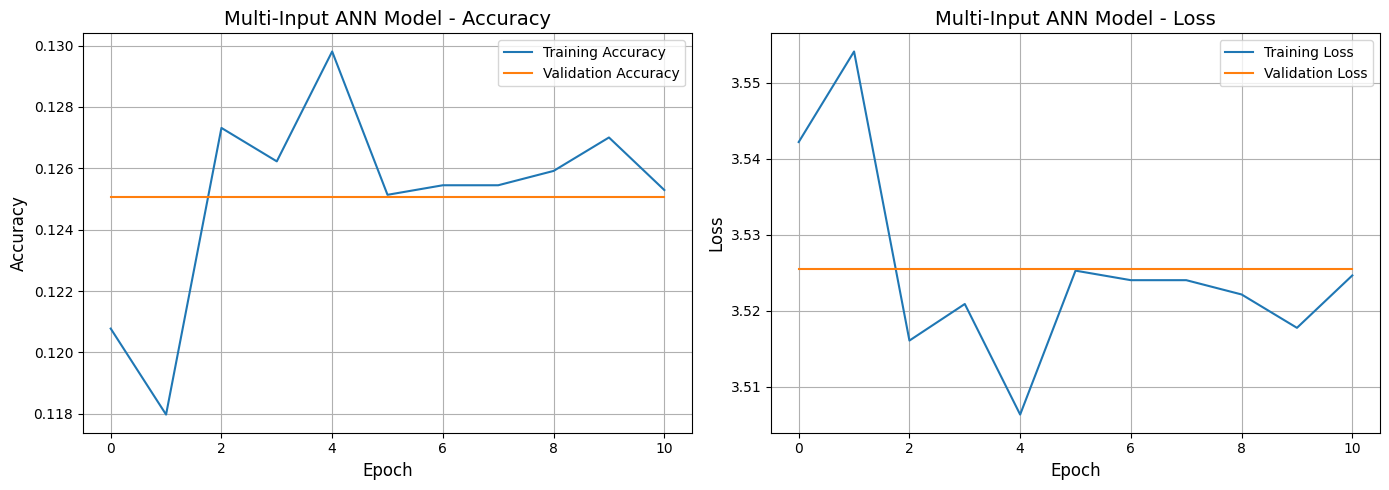

51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step


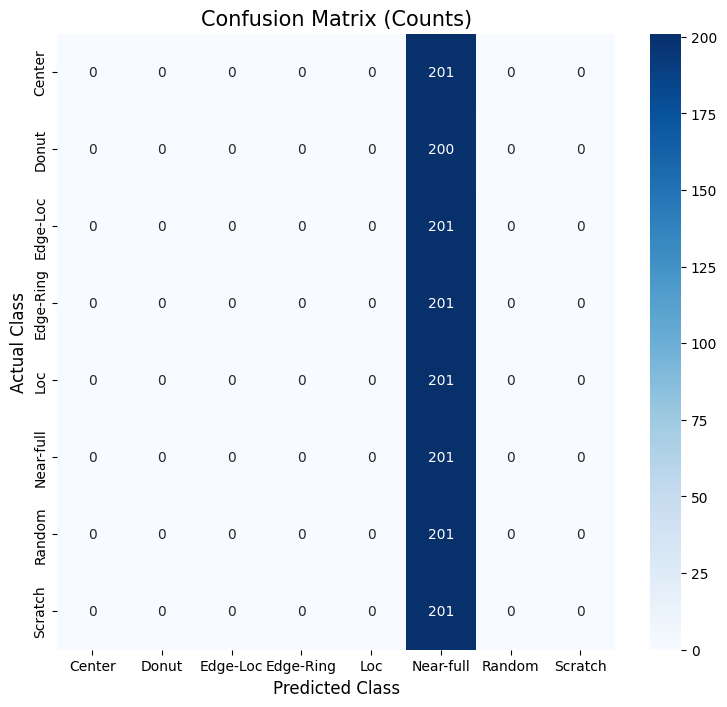

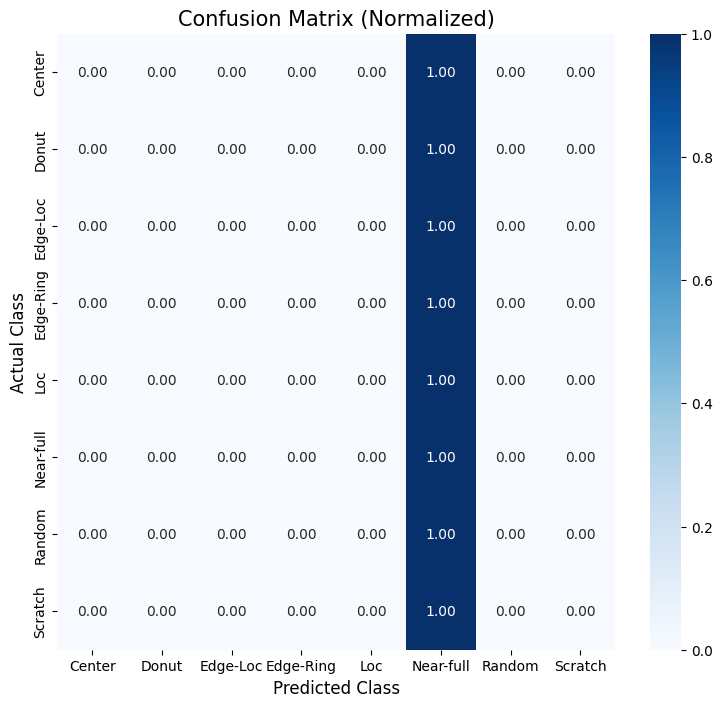

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_ann, "Multi-Input ANN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_ann.predict(X_test)

# 훈동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **4. Multi-Input CNN**

In [ ]:
# --- 모델 구성 ---

# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')
continuous_input = Input(shape=(10,), name='continuous')
rad_bin_input = Input(shape=(1,), name='radial_bin')
sec_bin_input = Input(shape=(1,), name='sector_bin')


# 이미지 처리 브랜치
x_img = Conv2D(32, (3, 3), activation='relu', padding='same')(image_input)
x_img = BatchNormalization()(x_img)
x_img = MaxPooling2D(pool_size=(2, 2))(x_img)
x_img = Dropout(0.3)(x_img)

x_img = Conv2D(64, (3, 3), activation='relu', padding='same')(x_img)
x_img = BatchNormalization()(x_img)
x_img = MaxPooling2D(pool_size=(2, 2))(x_img)
x_img = Dropout(0.3)(x_img)

x_img = Conv2D(128, (3, 3), activation='relu', padding='same')(x_img)
x_img = BatchNormalization()(x_img)
x_img = MaxPooling2D(pool_size=(2, 2))(x_img)
x_img = Dropout(0.5)(x_img)

image_features = Flatten()(x_img)


embedding_dim = 32

# 연속형 특징을 (None, 1, 32) 형태로 변환
split_features = Lambda(lambda x: tf.split(x, num_or_size_splits=10, axis=1))(continuous_input)
continuous_embeddings = []
for i, feature_tensor in enumerate(split_features):
    embedding = Dense(embedding_dim, name=f'cont_embed_{i}')(feature_tensor)
    # Reshape으로 차원을 (None, 1, 32)로 맞춥니다.
    reshaped_embedding = Reshape((1, embedding_dim))(embedding)
    continuous_embeddings.append(reshaped_embedding)

# 범주형 특징 임베딩
rad_bin_embedding = Embedding(input_dim=8, output_dim=embedding_dim, name='rad_embed')(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=embedding_dim, name='sec_embed')(sec_bin_input)

# 모든 토큰(임베딩) 결합
all_tokens = concatenate(continuous_embeddings + [rad_bin_embedding, sec_bin_embedding], axis=1)

# Transformer Encoder Block
num_transformer_blocks = 3
num_heads = 4
ff_dim = 32

x_coords = all_tokens
for i in range(num_transformer_blocks):
    # ... (Transformer Block 코드는 기존과 동일) ...
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, name=f'attention_{i}')(x_coords, x_coords)
    attn_output = Dropout(0.1)(attn_output)
    x_coords = LayerNormalization(name=f'layernorm1_{i}')(x_coords + attn_output)
    ffn_output = Dense(ff_dim, activation="relu", name=f'ffn_dense1_{i}')(x_coords)
    ffn_output = Dense(embedding_dim, name=f'ffn_dense2_{i}')(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)
    x_coords = LayerNormalization(name=f'layernorm2_{i}')(x_coords + ffn_output)

# Transformer를 통과한 최종 좌표 특징
coords_features = Flatten()(x_coords)


# 브랜치 통합
combined = concatenate([image_features, coords_features])


# 최종 출력층
x = Dense(128, activation='relu')(combined)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 모델 구성
model_cnn = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_cnn.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 통합
model_cnn.summary()


# --- 모델 훈련 ---
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ continuous          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ [(None, 1),       │          0 │ continuous[0][0]  │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1),    │            │                   │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1),    │            │                   │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1)]    │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_0        │ (None, 32)        │         64 │ lambda_7[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_1        │ (None, 32)        │         64 │ lambda_7[0][1]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_2        │ (None, 32)        │         64 │ lambda_7[0][2]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_3        │ (None, 32)        │         64 │ lambda_7[0][3]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_4        │ (None, 32)        │         64 │ lambda_7[0][4]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_5        │ (None, 32)        │         64 │ lambda_7[0][5]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_6        │ (None, 32)        │         64 │ lambda_7[0][6]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_7        │ (None, 32)        │         64 │ lambda_7[0][7]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_8        │ (None, 32)        │         64 │ lambda_7[0][8]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_9        │ (None, 32)        │         64 │ lambda_7[0][9]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ radial_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sector_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_40          │ (None, 1, 32)     │          0 │ cont_embed_0[0][… │
│ (Reshape)           │                   │            │                 

 Total params: 4,397,800 (16.78 MB)

 Trainable params: 4,397,096 (16.77 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 50s 115ms/step - accuracy: 0.5982 - loss: 0.2582 - val_accuracy: 0.8152 - val_loss: 0.0800
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8137 - loss: 0.0886 - val_accuracy: 0.7635 - val_loss: 0.1167
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8658 - loss: 0.0625 - val_accuracy: 0.7187 - val_loss: 0.1608
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8809 - loss: 0.0496 - val_accuracy: 0.7324 - val_loss: 0.1813
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8861 - loss: 0.0448 - val_accuracy: 0.7598 - val_loss: 0.1691
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8906 - loss: 0.0441 - val_accuracy: 0.7337 - val_loss: 0.2345
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8989 - loss: 0.0403 - val_accuracy: 0.7256 - val_loss: 0.3084
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9124 - loss: 0.0335 

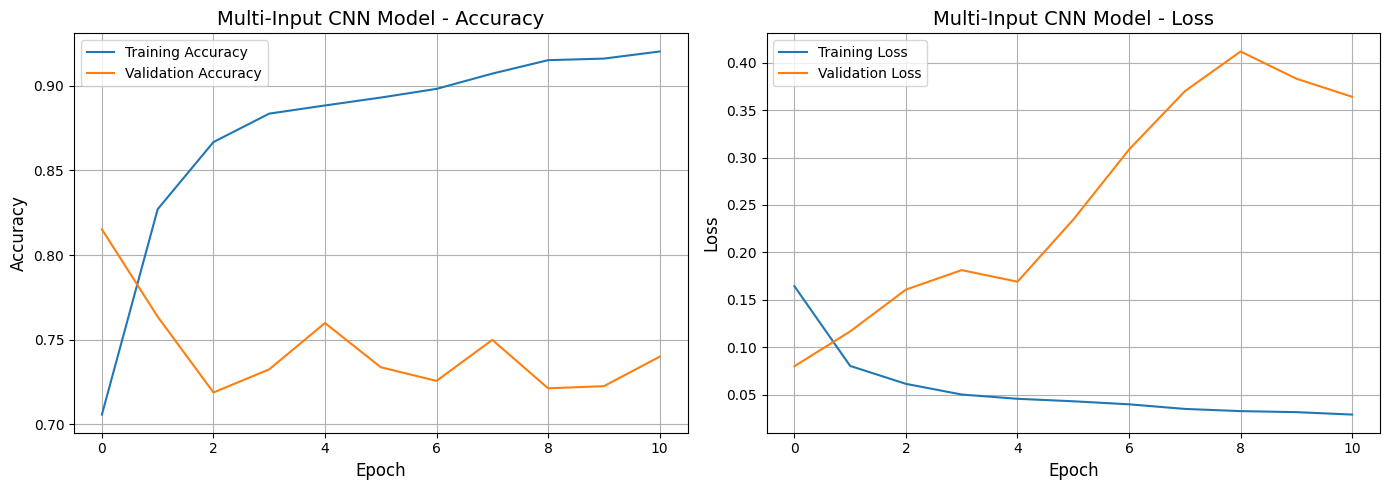

51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step


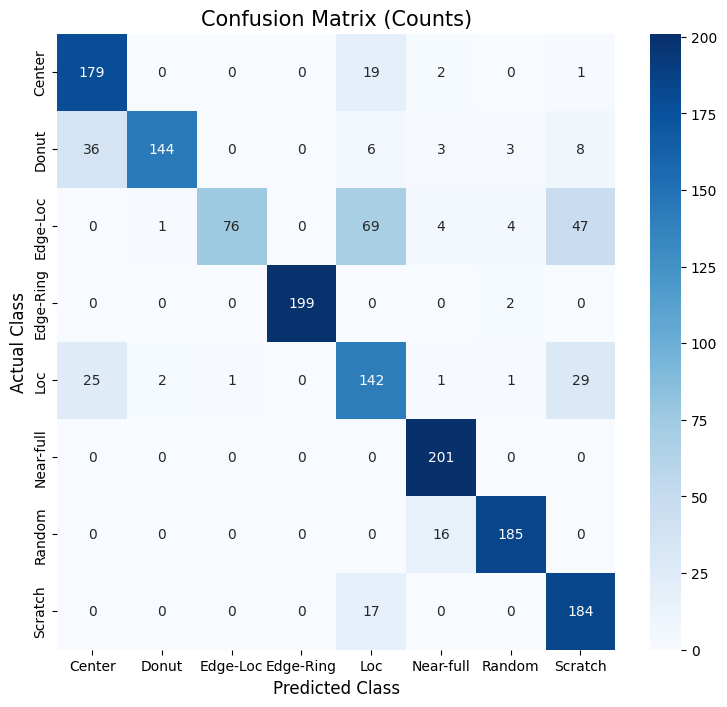

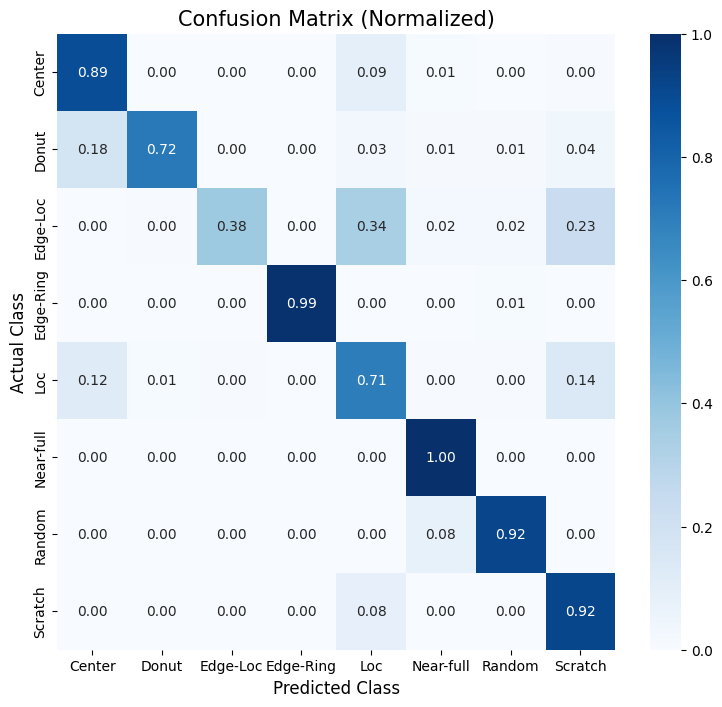

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_cnn, "Multi-Input CNN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_cnn.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **5. MobileNetV2 전이학습**

In [ ]:
# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')
continuous_input = Input(shape=(10,), name='continuous')
rad_bin_input = Input(shape=(1,), name='radial_bin')
sec_bin_input = Input(shape=(1,), name='sector_bin')


# MobileNetV2 모델 불러오기
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 MobileNetV2의 가중치 동결
base_model.trainable = False

# 이미지 처리 브랜치
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)

embedding_dim = 32

# 연속형 특징을 (None, 1, 32) 형태로 변환
split_features = Lambda(lambda x: tf.split(x, num_or_size_splits=10, axis=1))(continuous_input)
continuous_embeddings = []
for i, feature_tensor in enumerate(split_features):
    embedding = Dense(embedding_dim, name=f'cont_embed_{i}')(feature_tensor)
    # Reshape으로 차원을 (None, 1, 32)로 맞춥니다.
    reshaped_embedding = Reshape((1, embedding_dim))(embedding)
    continuous_embeddings.append(reshaped_embedding)

# 범주형 특징 임베딩
rad_bin_embedding = Embedding(input_dim=8, output_dim=embedding_dim, name='rad_embed')(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=embedding_dim, name='sec_embed')(sec_bin_input)

# 모든 토큰(임베딩) 결합
all_tokens = concatenate(continuous_embeddings + [rad_bin_embedding, sec_bin_embedding], axis=1)

# Transformer Encoder Block
num_transformer_blocks = 3
num_heads = 4
ff_dim = 32

x_coords = all_tokens
for i in range(num_transformer_blocks):
    # ... (Transformer Block 코드는 기존과 동일) ...
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, name=f'attention_{i}')(x_coords, x_coords)
    attn_output = Dropout(0.1)(attn_output)
    x_coords = LayerNormalization(name=f'layernorm1_{i}')(x_coords + attn_output)
    ffn_output = Dense(ff_dim, activation="relu", name=f'ffn_dense1_{i}')(x_coords)
    ffn_output = Dense(embedding_dim, name=f'ffn_dense2_{i}')(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)
    x_coords = LayerNormalization(name=f'layernorm2_{i}')(x_coords + ffn_output)

# Transformer를 통과한 최종 좌표 특징
coords_features = Flatten()(x_coords)


# 브랜치 통합
combined = concatenate([image_features, coords_features])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 모델 구성
model_mobilenetv2 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_mobilenetv2.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 불러오기
model_mobilenetv2.summary()


# --- 모델 훈련 ---
history_mobilenetv2 = model_mobilenetv2.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

/tmp/ipython-input-313357889.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,513,832 (9.59 MB)

 Trainable params: 255,848 (999.41 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 52s 127ms/step - accuracy: 0.2763 - loss: 0.4219 - val_accuracy: 0.7430 - val_loss: 0.1208
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5942 - loss: 0.1713 - val_accuracy: 0.8015 - val_loss: 0.0754
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6851 - loss: 0.1246 - val_accuracy: 0.8363 - val_loss: 0.0624
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7254 - loss: 0.1050 - val_accuracy: 0.8625 - val_loss: 0.0531
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7501 - loss: 0.0980 - val_accuracy: 0.8737 - val_loss: 0.0511
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7727 - loss: 0.0909 - val_accuracy: 0.8780 - val_loss: 0.0483
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7952 - loss: 0.0798 - val_accuracy: 0.8793 - val_loss: 0.0444
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8158 - loss: 0.0747 

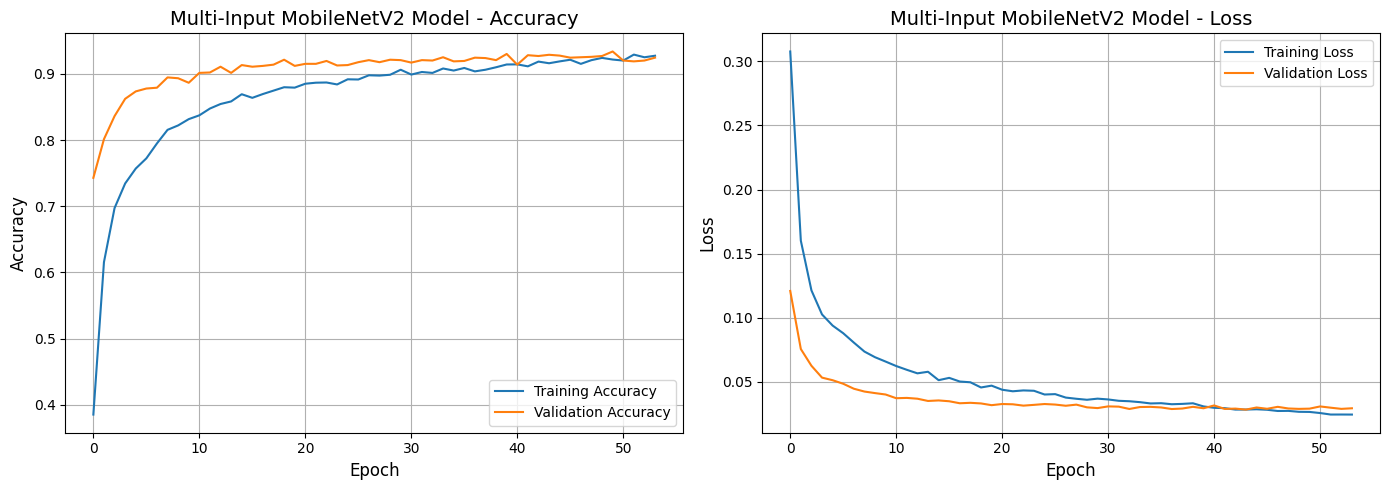

51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step


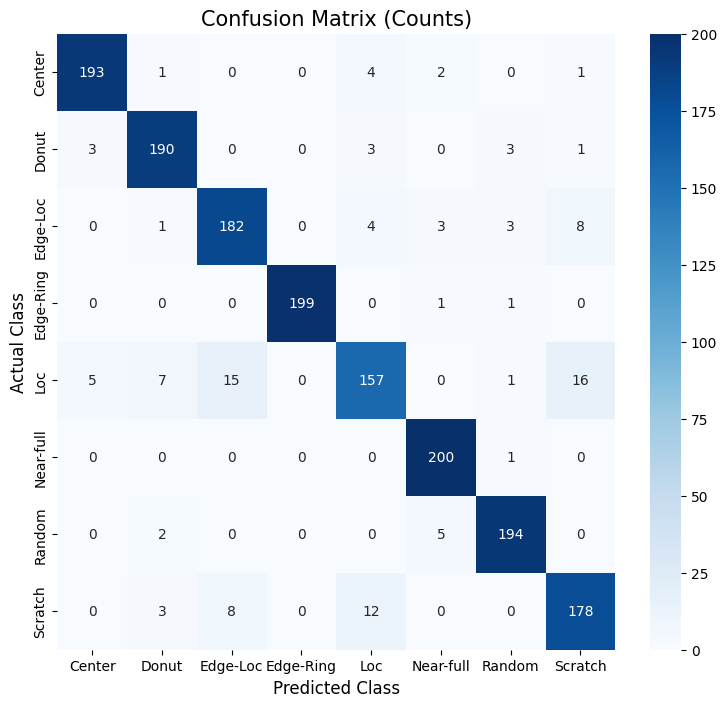

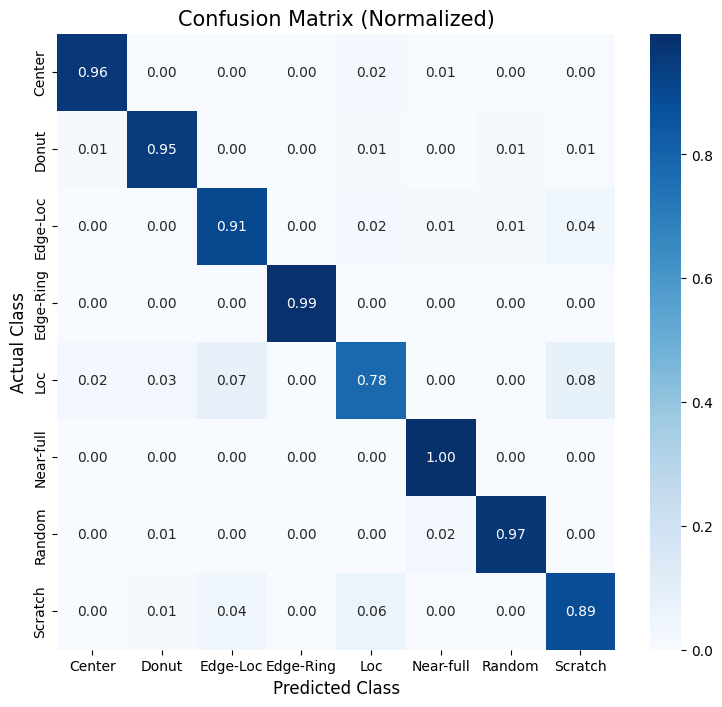

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_mobilenetv2, "Multi-Input MobileNetV2 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_mobilenetv2.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **6. MobileNetV3Small 전이학습**

In [ ]:
# --- 모델 구성 ---
# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')
continuous_input = Input(shape=(10,), name='continuous')
rad_bin_input = Input(shape=(1,), name='radial_bin')
sec_bin_input = Input(shape=(1,), name='sector_bin')


# 이미지 처리 브랜치
base_model = MobileNetV3Small(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃

embedding_dim = 32

# 연속형 특징을 (None, 1, 32) 형태로 변환
split_features = Lambda(lambda x: tf.split(x, num_or_size_splits=10, axis=1))(continuous_input)
continuous_embeddings = []
for i, feature_tensor in enumerate(split_features):
    embedding = Dense(embedding_dim, name=f'cont_embed_{i}')(feature_tensor)
    # Reshape으로 차원을 (None, 1, 32)로 맞춥니다.
    reshaped_embedding = Reshape((1, embedding_dim))(embedding)
    continuous_embeddings.append(reshaped_embedding)

# 범주형 특징 임베딩
rad_bin_embedding = Embedding(input_dim=8, output_dim=embedding_dim, name='rad_embed')(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=embedding_dim, name='sec_embed')(sec_bin_input)

# 모든 토큰(임베딩) 결합
all_tokens = concatenate(continuous_embeddings + [rad_bin_embedding, sec_bin_embedding], axis=1)

# Transformer Encoder Block
num_transformer_blocks = 3
num_heads = 4
ff_dim = 32

x_coords = all_tokens
for i in range(num_transformer_blocks):
    # ... (Transformer Block 코드는 기존과 동일) ...
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, name=f'attention_{i}')(x_coords, x_coords)
    attn_output = Dropout(0.1)(attn_output)
    x_coords = LayerNormalization(name=f'layernorm1_{i}')(x_coords + attn_output)
    ffn_output = Dense(ff_dim, activation="relu", name=f'ffn_dense1_{i}')(x_coords)
    ffn_output = Dense(embedding_dim, name=f'ffn_dense2_{i}')(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)
    x_coords = LayerNormalization(name=f'layernorm2_{i}')(x_coords + ffn_output)

# Transformer를 통과한 최종 좌표 특징
coords_features = Flatten()(x_coords)


# 브랜치 통합
combined = concatenate([image_features, coords_features])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_mobilenetv3 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_mobilenetv3.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 전체 모델 구조 출력
model_mobilenetv3.summary()


# --- 모델 훈련 ---
history_mobilenetv3 = model_mobilenetv3.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

/usr/local/lib/python3.11/dist-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ image[0][0]       │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 64, 64,    │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 64, 64,    │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 65, 65,    │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add_36[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 32, 32,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        256 │ expanded_conv_sq

 Total params: 1,104,856 (4.21 MB)

 Trainable params: 165,736 (647.41 KB)

 Non-trainable params: 939,120 (3.58 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 53s 130ms/step - accuracy: 0.2813 - loss: 0.4234 - val_accuracy: 0.7399 - val_loss: 0.1178
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5407 - loss: 0.1858 - val_accuracy: 0.8227 - val_loss: 0.0717
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6484 - loss: 0.1330 - val_accuracy: 0.8668 - val_loss: 0.0564
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7093 - loss: 0.1108 - val_accuracy: 0.8749 - val_loss: 0.0492
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7637 - loss: 0.0947 - val_accuracy: 0.8799 - val_loss: 0.0457
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7810 - loss: 0.0824 - val_accuracy: 0.8880 - val_loss: 0.0444
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7993 - loss: 0.0757 - val_accuracy: 0.8911 - val_loss: 0.0414
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8088 - loss: 0.0719 

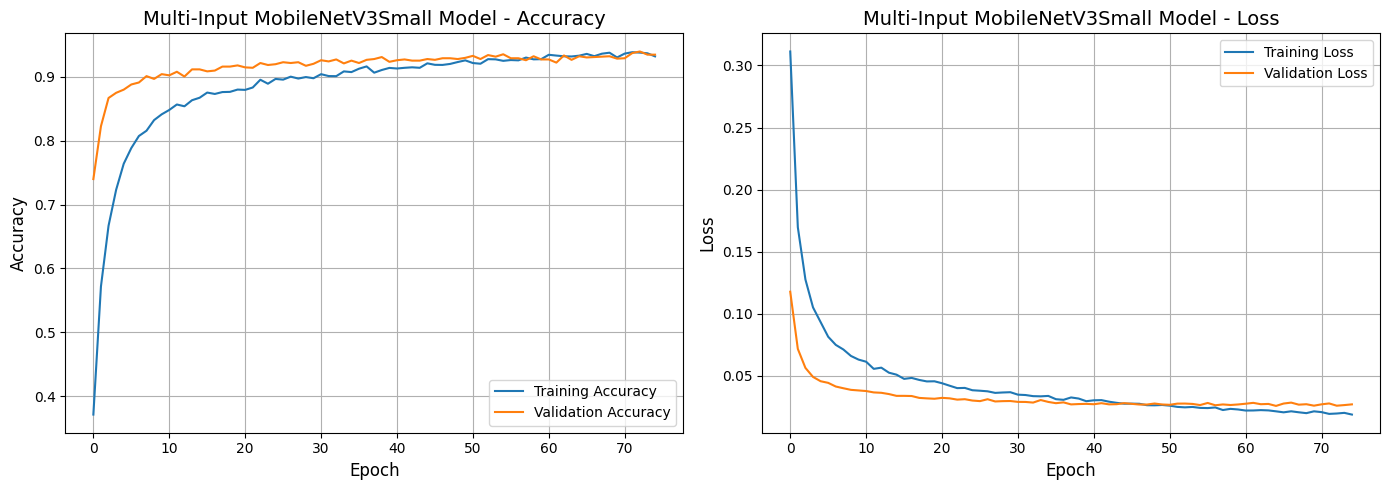

51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step


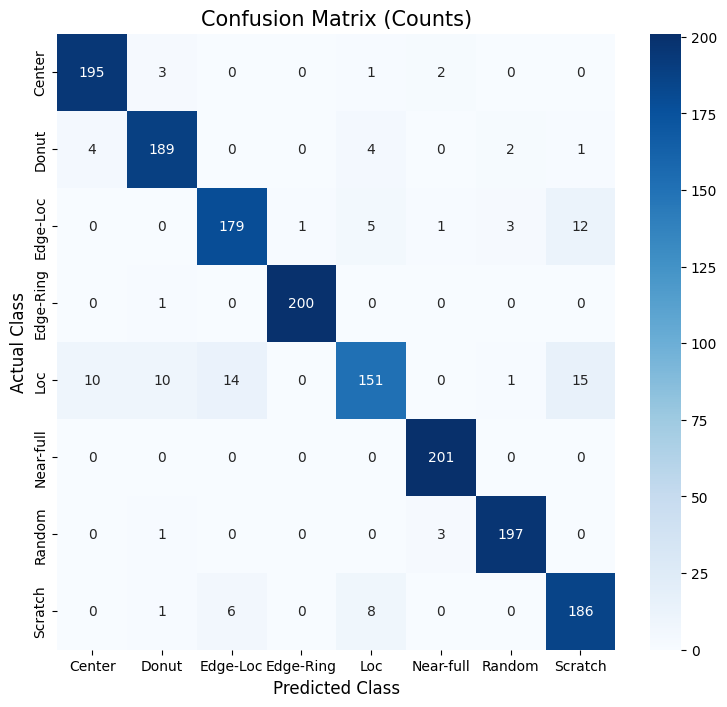

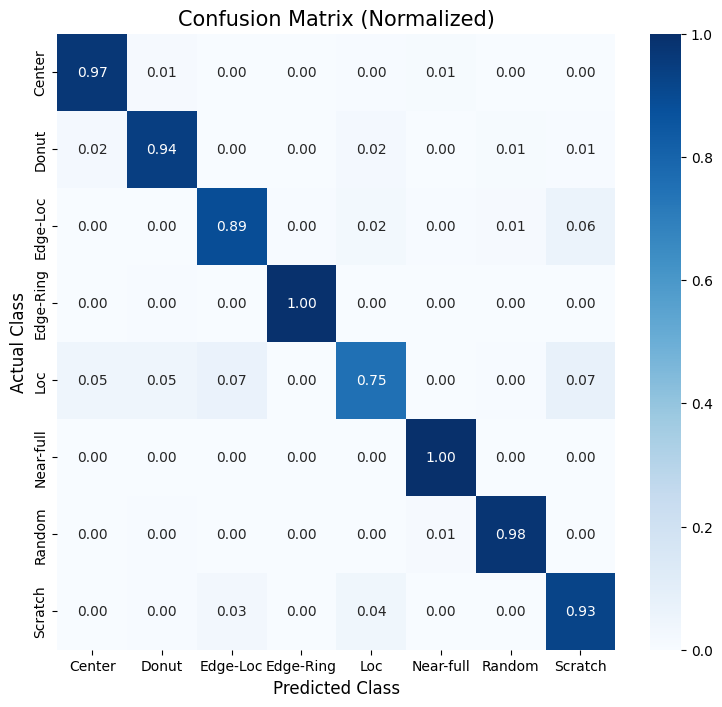

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_mobilenetv3, "Multi-Input MobileNetV3Small Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_mobilenetv3.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **7. ResNet50 전이학습**

In [ ]:
# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')
continuous_input = Input(shape=(10,), name='continuous')
rad_bin_input = Input(shape=(1,), name='radial_bin')
sec_bin_input = Input(shape=(1,), name='sector_bin')


# 이미지 처리 브랜치 (ResNet50)
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# ResNet50 모델의 출력에 새로운 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃

embedding_dim = 32

# 연속형 특징을 (None, 1, 32) 형태로 변환
split_features = Lambda(lambda x: tf.split(x, num_or_size_splits=10, axis=1))(continuous_input)
continuous_embeddings = []
for i, feature_tensor in enumerate(split_features):
    embedding = Dense(embedding_dim, name=f'cont_embed_{i}')(feature_tensor)
    # Reshape으로 차원을 (None, 1, 32)로 맞춥니다.
    reshaped_embedding = Reshape((1, embedding_dim))(embedding)
    continuous_embeddings.append(reshaped_embedding)

# 범주형 특징 임베딩
rad_bin_embedding = Embedding(input_dim=8, output_dim=embedding_dim, name='rad_embed')(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=embedding_dim, name='sec_embed')(sec_bin_input)

# 모든 토큰(임베딩) 결합
all_tokens = concatenate(continuous_embeddings + [rad_bin_embedding, sec_bin_embedding], axis=1)

# Transformer Encoder Block
num_transformer_blocks = 3
num_heads = 4
ff_dim = 32

x_coords = all_tokens
for i in range(num_transformer_blocks):
    # ... (Transformer Block 코드는 기존과 동일) ...
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, name=f'attention_{i}')(x_coords, x_coords)
    attn_output = Dropout(0.1)(attn_output)
    x_coords = LayerNormalization(name=f'layernorm1_{i}')(x_coords + attn_output)
    ffn_output = Dense(ff_dim, activation="relu", name=f'ffn_dense1_{i}')(x_coords)
    ffn_output = Dense(embedding_dim, name=f'ffn_dense2_{i}')(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)
    x_coords = LayerNormalization(name=f'layernorm2_{i}')(x_coords + ffn_output)

# Transformer를 통과한 최종 좌표 특징
coords_features = Flatten()(x_coords)


# 브랜치 통합
combined = concatenate([image_features, coords_features])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_resnet50 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_resnet50.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 전체 구조 출력
model_resnet50.summary()


# --- 모델 훈련 ---
history_resnet50 = model_resnet50.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ image[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,941,864 (91.33 MB)

 Trainable params: 354,152 (1.35 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 61s 156ms/step - accuracy: 0.3027 - loss: 0.4483 - val_accuracy: 0.7990 - val_loss: 0.1118
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.6023 - loss: 0.1820 - val_accuracy: 0.8507 - val_loss: 0.0693
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.6992 - loss: 0.1296 - val_accuracy: 0.8768 - val_loss: 0.0549
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.7514 - loss: 0.1046 - val_accuracy: 0.8818 - val_loss: 0.0468
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.7726 - loss: 0.0939 - val_accuracy: 0.8886 - val_loss: 0.0425
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.7997 - loss: 0.0801 - val_accuracy: 0.8955 - val_loss: 0.0402
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.8192 - loss: 0.0717 - val_accuracy: 0.9023 - val_loss: 0.0387
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.8290 - loss: 0.0710 

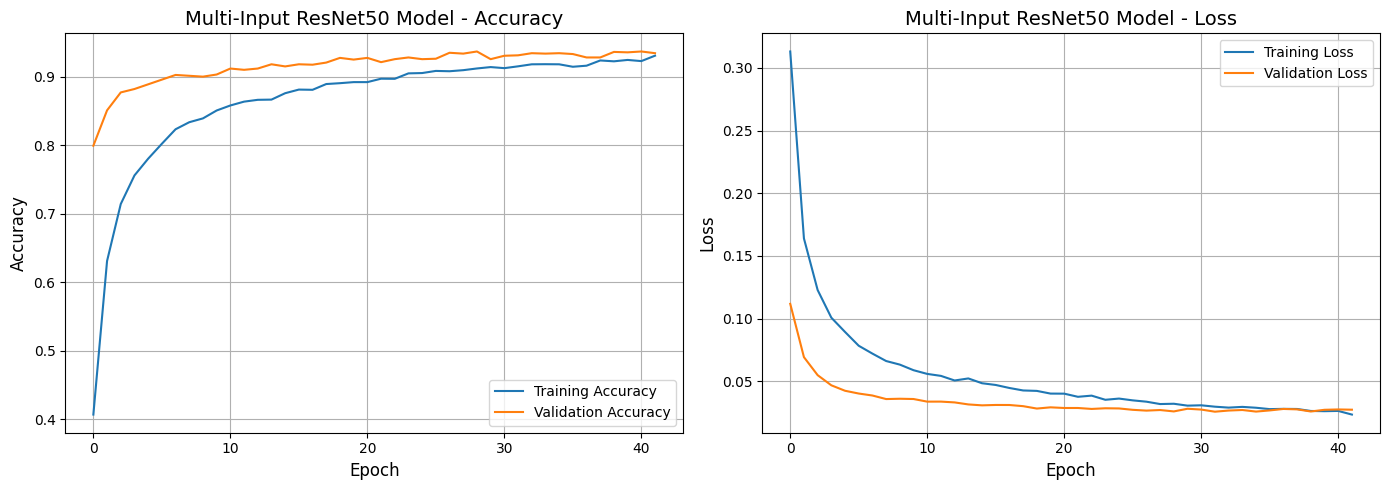

51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 139ms/step


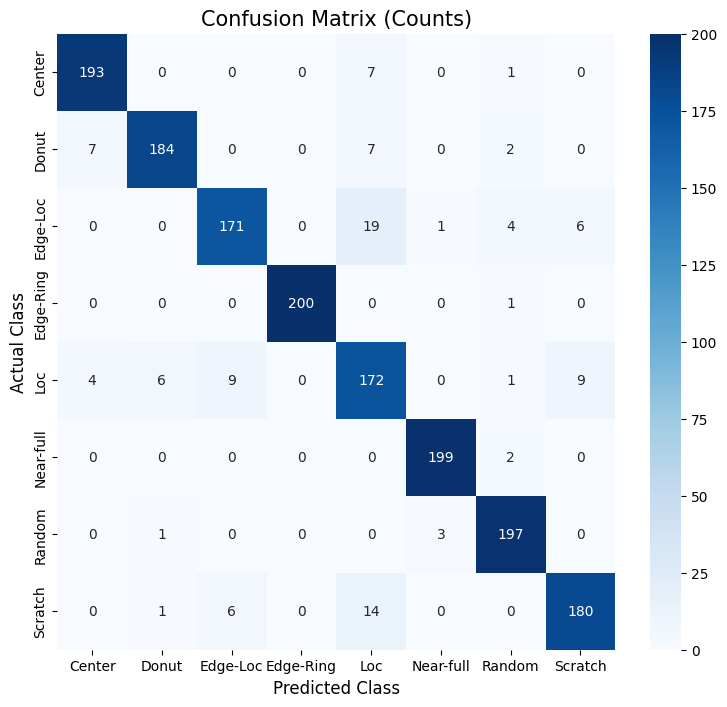

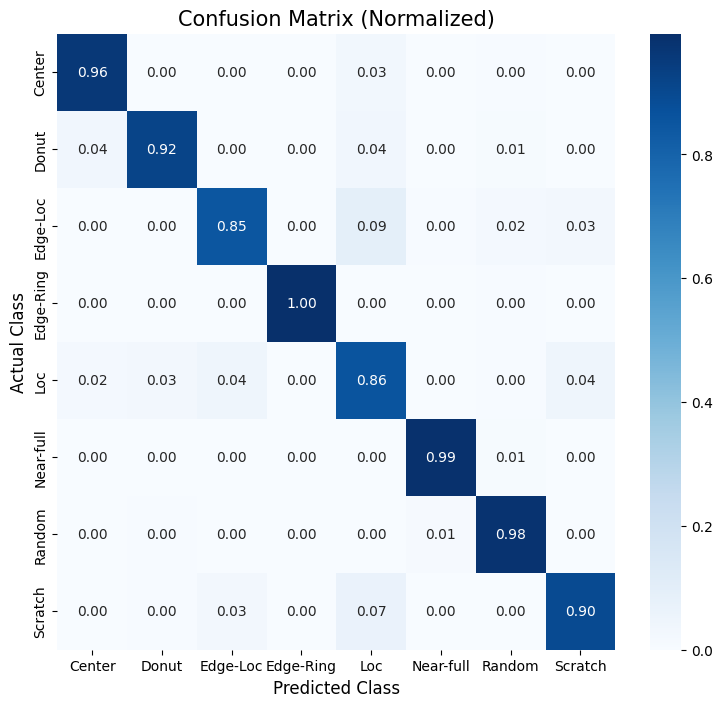

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_resnet50, "Multi-Input ResNet50 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_resnet50.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **8. VGG16 전이학습**

In [ ]:
# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')                 # 이미지 입력
continuous_input = Input(shape=(10,), name='continuous')              # 10차원 연속형 특징 입력
rad_bin_input = Input(shape=(1,), name='radial_bin')                   # 반경 구간 ID 입력
sec_bin_input = Input(shape=(1,), name='sector_bin')                   # 섹터 구간 ID 입력


# 이미지 처리 브랜치 (VGG16)
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# VGG16 모델의 출력에 새로운 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃

embedding_dim = 32

# 연속형 특징을 (None, 1, 32) 형태로 변환
split_features = Lambda(lambda x: tf.split(x, num_or_size_splits=10, axis=1))(continuous_input)
continuous_embeddings = []
for i, feature_tensor in enumerate(split_features):
    embedding = Dense(embedding_dim, name=f'cont_embed_{i}')(feature_tensor)
    # Reshape으로 차원을 (None, 1, 32)로 맞춥니다.
    reshaped_embedding = Reshape((1, embedding_dim))(embedding)
    continuous_embeddings.append(reshaped_embedding)

# 범주형 특징 임베딩
rad_bin_embedding = Embedding(input_dim=8, output_dim=embedding_dim, name='rad_embed')(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=embedding_dim, name='sec_embed')(sec_bin_input)

# 모든 토큰(임베딩) 결합
all_tokens = concatenate(continuous_embeddings + [rad_bin_embedding, sec_bin_embedding], axis=1)

# Transformer Encoder Block
num_transformer_blocks = 3
num_heads = 4
ff_dim = 32

x_coords = all_tokens
for i in range(num_transformer_blocks):
    # ... (Transformer Block 코드는 기존과 동일) ...
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, name=f'attention_{i}')(x_coords, x_coords)
    attn_output = Dropout(0.1)(attn_output)
    x_coords = LayerNormalization(name=f'layernorm1_{i}')(x_coords + attn_output)
    ffn_output = Dense(ff_dim, activation="relu", name=f'ffn_dense1_{i}')(x_coords)
    ffn_output = Dense(embedding_dim, name=f'ffn_dense2_{i}')(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)
    x_coords = LayerNormalization(name=f'layernorm2_{i}')(x_coords + ffn_output)

# Transformer를 통과한 최종 좌표 특징
coords_features = Flatten()(x_coords)


# 브랜치 통합
combined = concatenate([image_features, coords_features])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
# num_classes는 이전에 계산된 클래스의 총 개수입니다.
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_vgg16 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_vgg16.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 전체 구조 출력
model_vgg16.summary()


# --- 모델 훈련 ---
history_vgg16 = model_vgg16.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ continuous          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ [(None, 1),       │          0 │ continuous[0][0]  │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1),    │            │                   │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1),    │            │                   │
│                     │ (None, 1), (None, │            │                   │
│                     │ 1), (None, 1)]    │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_0        │ (None, 32)        │         64 │ lambda_11[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_1        │ (None, 32)        │         64 │ lambda_11[0][1]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_2        │ (None, 32)        │         64 │ lambda_11[0][2]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_3        │ (None, 32)        │         64 │ lambda_11[0][3]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_4        │ (None, 32)        │         64 │ lambda_11[0][4]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_5        │ (None, 32)        │         64 │ lambda_11[0][5]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_6        │ (None, 32)        │         64 │ lambda_11[0][6]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_7        │ (None, 32)        │         64 │ lambda_11[0][7]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_8        │ (None, 32)        │         64 │ lambda_11[0][8]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cont_embed_9        │ (None, 32)        │         64 │ lambda_11[0][9]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ radial_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sector_bin          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_80          │ (None, 1, 32)     │          0 │ cont_embed_0[0][… │
│ (Reshape)           │                   │            │                 

 Total params: 14,872,232 (56.73 MB)

 Trainable params: 157,544 (615.41 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 59s 178ms/step - accuracy: 0.1915 - loss: 1.7273 - val_accuracy: 0.5887 - val_loss: 0.1964
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.3586 - loss: 0.4169 - val_accuracy: 0.5999 - val_loss: 0.1956
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.4472 - loss: 0.2776 - val_accuracy: 0.7094 - val_loss: 0.1375
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.5235 - loss: 0.2163 - val_accuracy: 0.7579 - val_loss: 0.1008
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.6102 - loss: 0.1706 - val_accuracy: 0.7915 - val_loss: 0.0777
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - accuracy: 0.6557 - loss: 0.1387 - val_accuracy: 0.8233 - val_loss: 0.0665
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.6852 - loss: 0.1231 - val_accuracy: 0.8276 - val_loss: 0.0609
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.7111 - loss: 

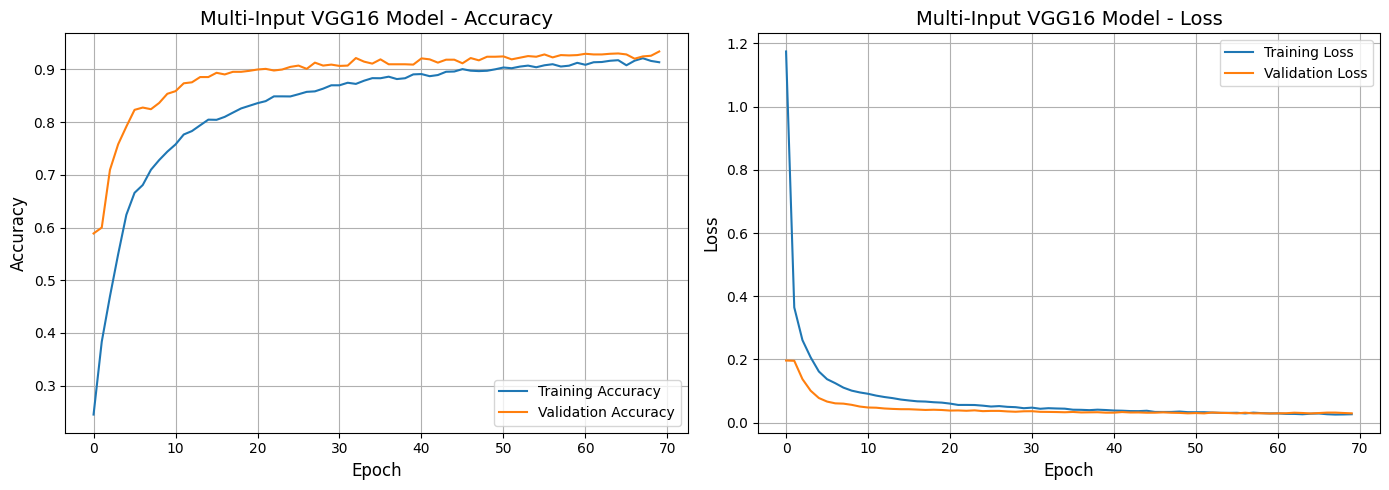

51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step


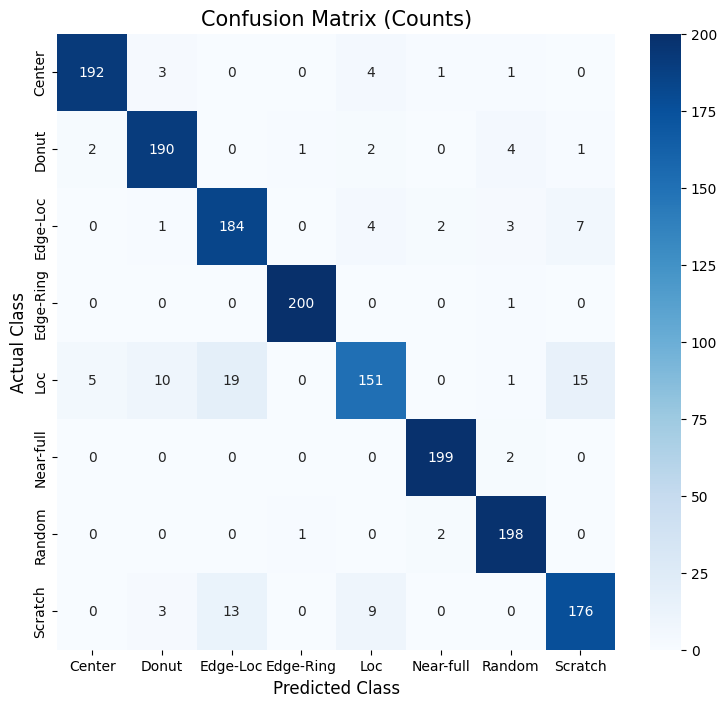

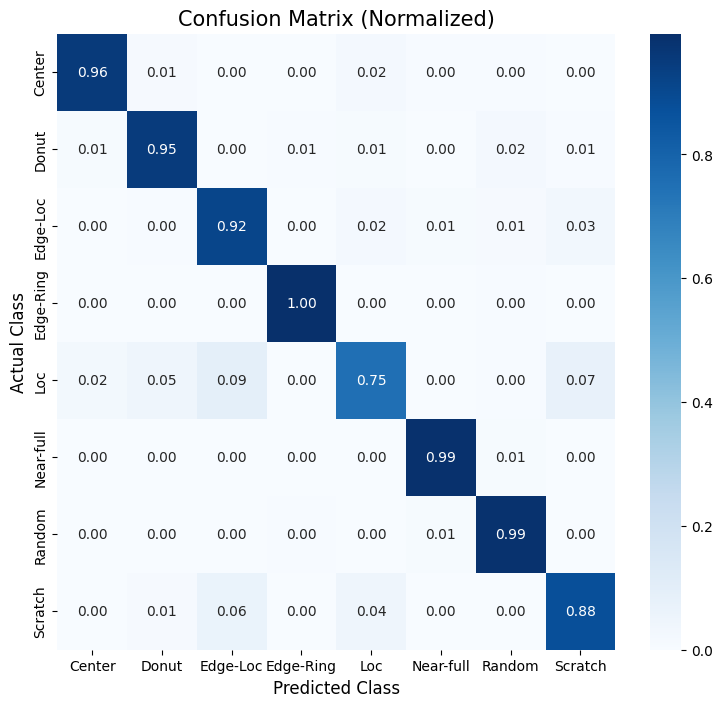

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_vgg16, "Multi-Input VGG16 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_vgg16.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **9. InceptionV3 전이학습**

In [ ]:
# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')                 # 이미지 입력
continuous_input = Input(shape=(10,), name='continuous')              # 10차원 연속형 특징 입력
rad_bin_input = Input(shape=(1,), name='radial_bin')                   # 반경 구간 ID 입력
sec_bin_input = Input(shape=(1,), name='sector_bin')                   # 섹터 구간 ID 입력


# 이미지 처리 브랜치 (InceptionV3)
base_model = InceptionV3(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃


embedding_dim = 32

# 연속형 특징을 (None, 1, 32) 형태로 변환
split_features = Lambda(lambda x: tf.split(x, num_or_size_splits=10, axis=1))(continuous_input)
continuous_embeddings = []
for i, feature_tensor in enumerate(split_features):
    embedding = Dense(embedding_dim, name=f'cont_embed_{i}')(feature_tensor)
    # Reshape으로 차원을 (None, 1, 32)로 맞춥니다.
    reshaped_embedding = Reshape((1, embedding_dim))(embedding)
    continuous_embeddings.append(reshaped_embedding)

# 범주형 특징 임베딩
rad_bin_embedding = Embedding(input_dim=8, output_dim=embedding_dim, name='rad_embed')(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=embedding_dim, name='sec_embed')(sec_bin_input)

# 모든 토큰(임베딩) 결합
all_tokens = concatenate(continuous_embeddings + [rad_bin_embedding, sec_bin_embedding], axis=1)

# Transformer Encoder Block
num_transformer_blocks = 3
num_heads = 4
ff_dim = 32

x_coords = all_tokens
for i in range(num_transformer_blocks):
    # ... (Transformer Block 코드는 기존과 동일) ...
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, name=f'attention_{i}')(x_coords, x_coords)
    attn_output = Dropout(0.1)(attn_output)
    x_coords = LayerNormalization(name=f'layernorm1_{i}')(x_coords + attn_output)
    ffn_output = Dense(ff_dim, activation="relu", name=f'ffn_dense1_{i}')(x_coords)
    ffn_output = Dense(embedding_dim, name=f'ffn_dense2_{i}')(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)
    x_coords = LayerNormalization(name=f'layernorm2_{i}')(x_coords + ffn_output)

# Transformer를 통과한 최종 좌표 특징
coords_features = Flatten()(x_coords)


# 브랜치 통합
combined = concatenate([image_features, coords_features])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_inceptionv3 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_inceptionv3.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 전체 구조 출력
model_inceptionv3.summary()


# --- 모델 훈련 ---
history_inceptionv3 = model_inceptionv3.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 63, 63,    │        864 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 63, 63,    │         96 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 63, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 61, 61,    │      9,216 │ activation_18[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │         96 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 61, 61,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 61, 61,    │     18,432 │ activation_19[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │        192 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 61, 61,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 30, 30,    │          0 │ activation_20[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 30, 30,    │      5,120 │ max_pooling2d_3[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 30,    │        240 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 30, 30,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │    138,240 │ activation_21[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        576 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 22,156,936 (84.52 MB)

 Trainable params: 354,152 (1.35 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 69s 183ms/step - accuracy: 0.1497 - loss: 3.2428 - val_accuracy: 0.4941 - val_loss: 1.5525
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.3230 - loss: 2.2859 - val_accuracy: 0.6297 - val_loss: 0.1634
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.4703 - loss: 0.2507 - val_accuracy: 0.7144 - val_loss: 0.1034
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.5751 - loss: 0.1631 - val_accuracy: 0.7380 - val_loss: 0.0929
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6079 - loss: 0.1457 - val_accuracy: 0.7505 - val_loss: 0.0845
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6317 - loss: 0.1378 - val_accuracy: 0.7673 - val_loss: 0.0796
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6404 - loss: 0.1340 - val_accuracy: 0.7704 - val_loss: 0.0779
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6809 - loss: 0.1192 

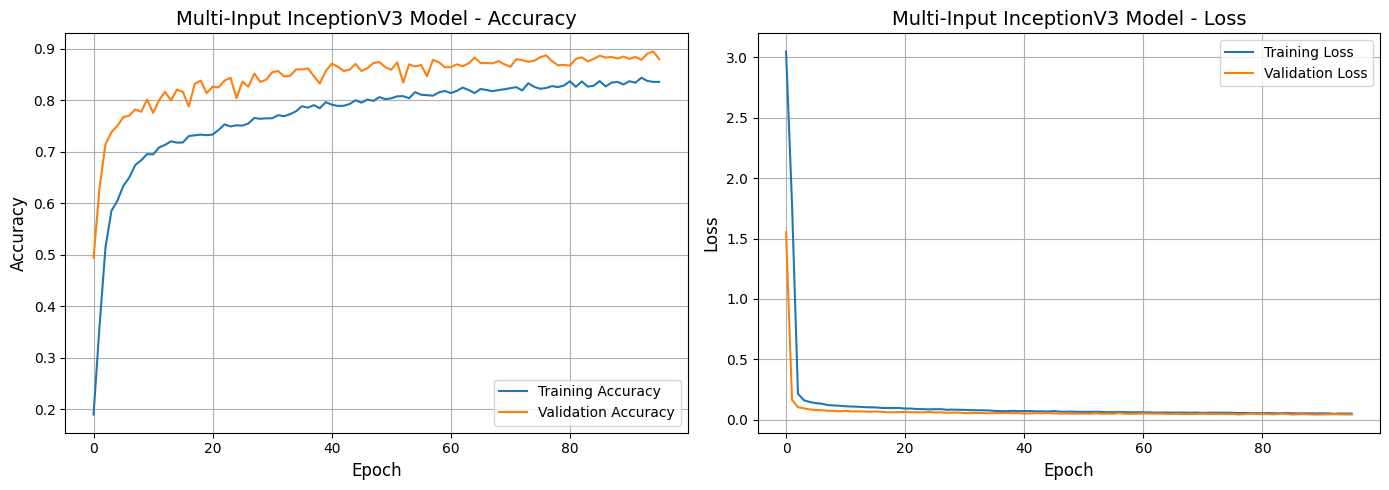

51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 172ms/step


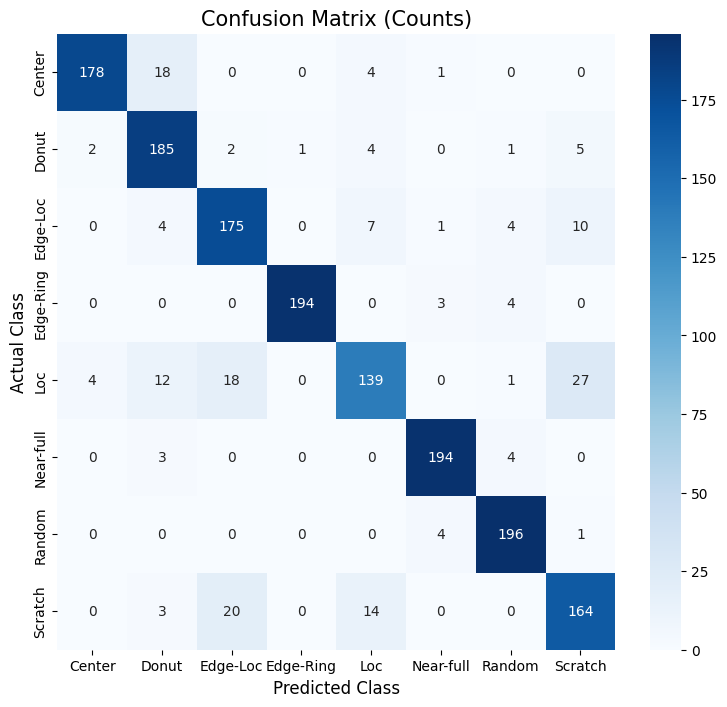

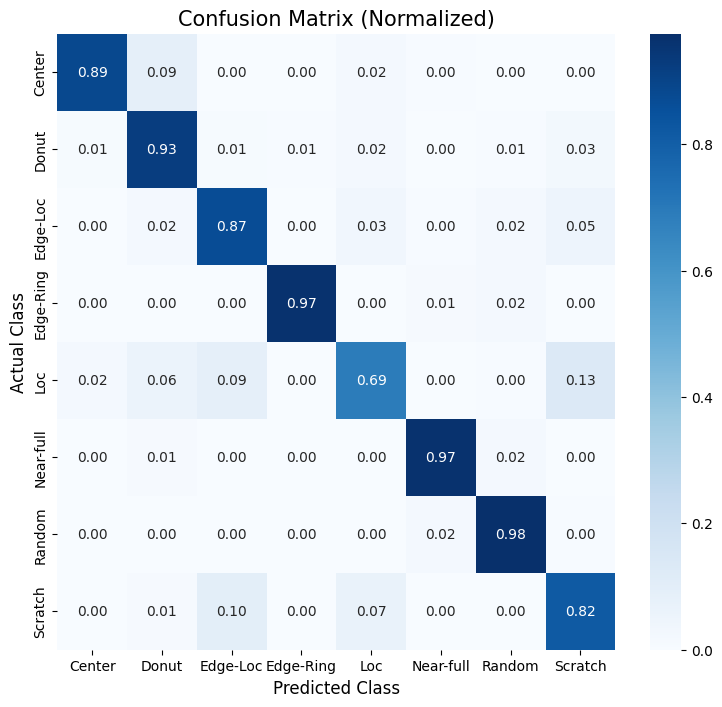

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_inceptionv3, "Multi-Input InceptionV3 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_inceptionv3.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **10. Xception 전이학습**

In [ ]:

# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')                 # 이미지 입력
continuous_input = Input(shape=(10,), name='continuous')              # 10차원 연속형 특징 입력
rad_bin_input = Input(shape=(1,), name='radial_bin')                   # 반경 구간 ID 입력
sec_bin_input = Input(shape=(1,), name='sector_bin')                   # 섹터 구간 ID 입력


# 이미지 처리 브랜치 (Xception)
base_model = Xception(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃


embedding_dim = 32

# 연속형 특징을 (None, 1, 32) 형태로 변환
split_features = Lambda(lambda x: tf.split(x, num_or_size_splits=10, axis=1))(continuous_input)
continuous_embeddings = []
for i, feature_tensor in enumerate(split_features):
    embedding = Dense(embedding_dim, name=f'cont_embed_{i}')(feature_tensor)
    # Reshape으로 차원을 (None, 1, 32)로 맞춥니다.
    reshaped_embedding = Reshape((1, embedding_dim))(embedding)
    continuous_embeddings.append(reshaped_embedding)

# 범주형 특징 임베딩
rad_bin_embedding = Embedding(input_dim=8, output_dim=embedding_dim, name='rad_embed')(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=embedding_dim, name='sec_embed')(sec_bin_input)

# 모든 토큰(임베딩) 결합
all_tokens = concatenate(continuous_embeddings + [rad_bin_embedding, sec_bin_embedding], axis=1)

# Transformer Encoder Block
num_transformer_blocks = 3
num_heads = 4
ff_dim = 32

x_coords = all_tokens
for i in range(num_transformer_blocks):
    # ... (Transformer Block 코드는 기존과 동일) ...
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, name=f'attention_{i}')(x_coords, x_coords)
    attn_output = Dropout(0.1)(attn_output)
    x_coords = LayerNormalization(name=f'layernorm1_{i}')(x_coords + attn_output)
    ffn_output = Dense(ff_dim, activation="relu", name=f'ffn_dense1_{i}')(x_coords)
    ffn_output = Dense(embedding_dim, name=f'ffn_dense2_{i}')(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)
    x_coords = LayerNormalization(name=f'layernorm2_{i}')(x_coords + ffn_output)

# Transformer를 통과한 최종 좌표 특징
coords_features = Flatten()(x_coords)


# 브랜치 통합
combined = concatenate([image_features, coords_features])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_xception = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_xception.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 전체 구조 출력
model_xception.summary()


# --- 모델 훈련 ---
history_xception = model_xception.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 63, 63,    │        864 │ image[0][0]       │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 63, 63,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 63, 63,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 61, 61,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 61, 61,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 61, 61,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 61, 61,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 61, 61,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 61, 61,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 61, 61,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 61, 61,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 31, 31,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 31, 31,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │        512 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_69 (Add)        │ (None, 31, 31,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 31, 31,    │          0 │ add_69[0][0]    

 Total params: 21,215,632 (80.93 MB)

 Trainable params: 354,152 (1.35 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 56s 154ms/step - accuracy: 0.1939 - loss: 2.0795 - val_accuracy: 0.5401 - val_loss: 0.2539
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.4134 - loss: 0.2899 - val_accuracy: 0.7492 - val_loss: 0.1091
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.5845 - loss: 0.1780 - val_accuracy: 0.7971 - val_loss: 0.0782
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6405 - loss: 0.1525 - val_accuracy: 0.8289 - val_loss: 0.0663
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6878 - loss: 0.1260 - val_accuracy: 0.8500 - val_loss: 0.0578
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7036 - loss: 0.1200 - val_accuracy: 0.8556 - val_loss: 0.0536
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7378 - loss: 0.1064 - val_accuracy: 0.8643 - val_loss: 0.0508
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7557 - loss: 

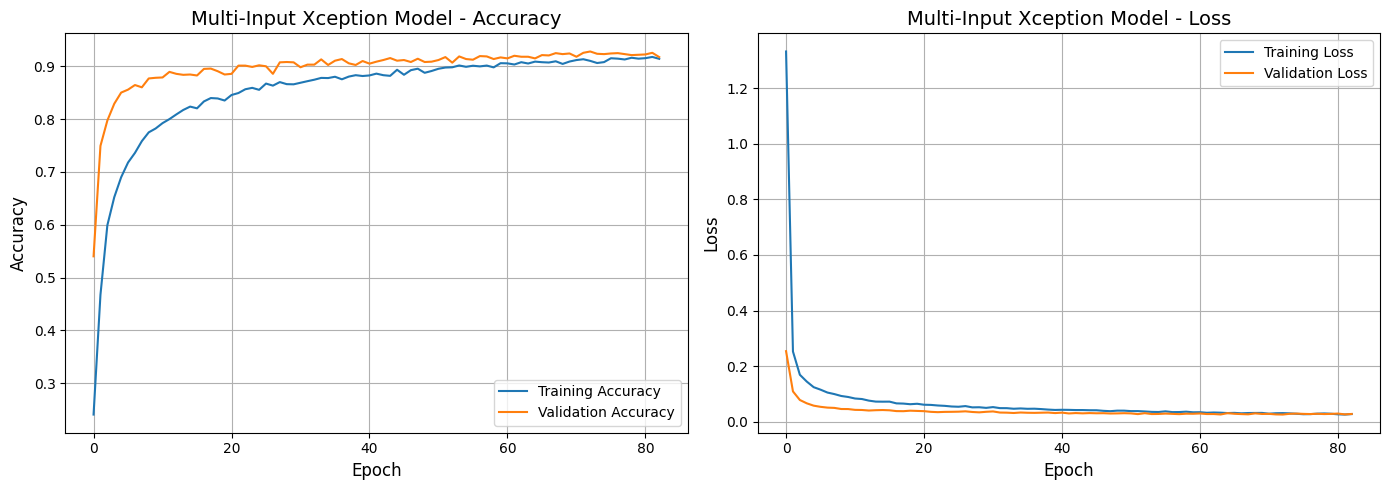

51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step


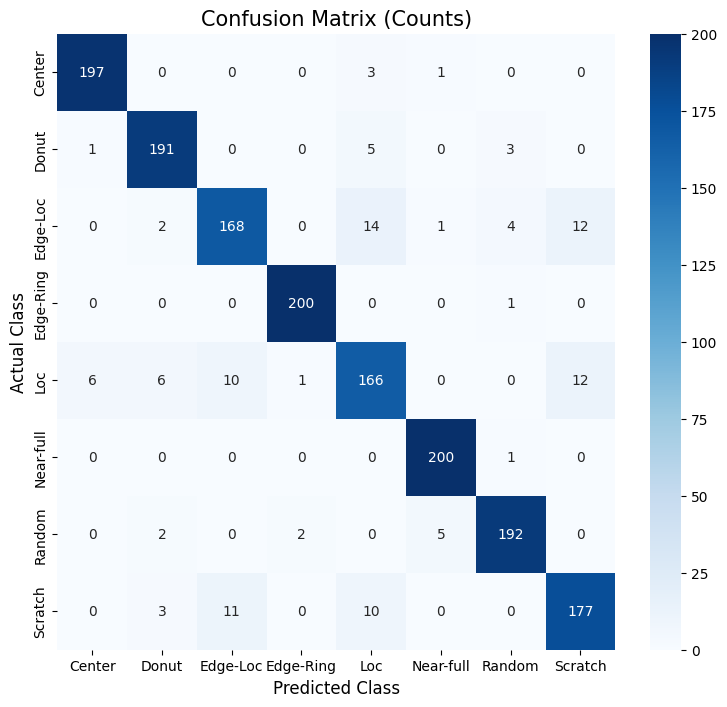

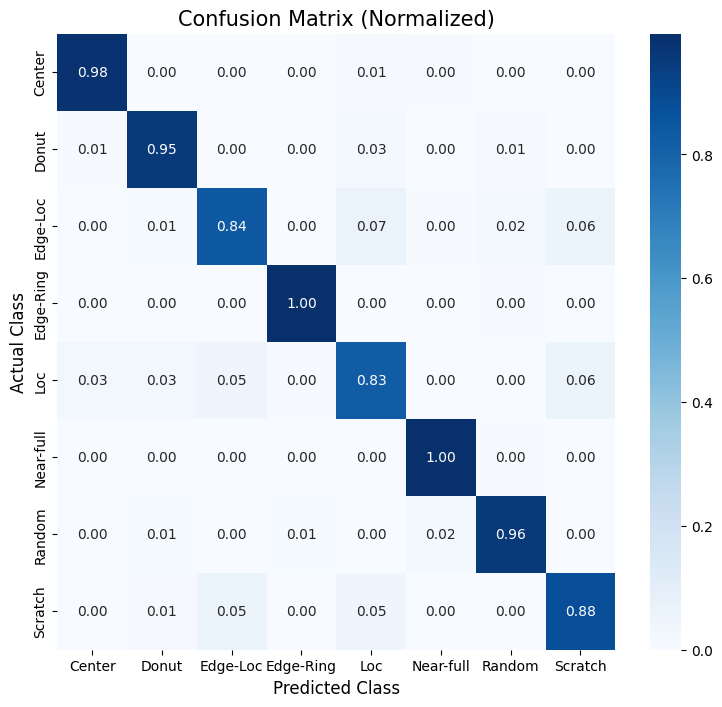

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_xception, "Multi-Input Xception Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_xception.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **11. DenseNet121 전이학습**

In [ ]:
# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image')                 # 이미지 입력
continuous_input = Input(shape=(10,), name='continuous')              # 10차원 연속형 특징 입력
rad_bin_input = Input(shape=(1,), name='radial_bin')                   # 반경 구간 ID 입력
sec_bin_input = Input(shape=(1,), name='sector_bin')                   # 섹터 구간 ID 입력


# 이미지 처리 브랜치 (DenseNet121)
base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 모델의 가중치 동결
base_model.trainable = False

# 분류층 추가
x_img = base_model.output
x_img = GlobalAveragePooling2D()(x_img)         # 채널별 평균값을 계산하여 벡터로 만듭니다.
x_img = Dense(128, activation='relu')(x_img)
image_features = Dropout(0.5)(x_img)            # 과적합 방지를 위한 드롭아웃

embedding_dim = 32

# 연속형 특징을 (None, 1, 32) 형태로 변환
split_features = Lambda(lambda x: tf.split(x, num_or_size_splits=10, axis=1))(continuous_input)
continuous_embeddings = []
for i, feature_tensor in enumerate(split_features):
    embedding = Dense(embedding_dim, name=f'cont_embed_{i}')(feature_tensor)
    # Reshape으로 차원을 (None, 1, 32)로 맞춥니다.
    reshaped_embedding = Reshape((1, embedding_dim))(embedding)
    continuous_embeddings.append(reshaped_embedding)

# 범주형 특징 임베딩
rad_bin_embedding = Embedding(input_dim=8, output_dim=embedding_dim, name='rad_embed')(rad_bin_input)
sec_bin_embedding = Embedding(input_dim=16, output_dim=embedding_dim, name='sec_embed')(sec_bin_input)

# 모든 토큰(임베딩) 결합
all_tokens = concatenate(continuous_embeddings + [rad_bin_embedding, sec_bin_embedding], axis=1)

# Transformer Encoder Block
num_transformer_blocks = 3
num_heads = 4
ff_dim = 32

x_coords = all_tokens
for i in range(num_transformer_blocks):
    # ... (Transformer Block 코드는 기존과 동일) ...
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, name=f'attention_{i}')(x_coords, x_coords)
    attn_output = Dropout(0.1)(attn_output)
    x_coords = LayerNormalization(name=f'layernorm1_{i}')(x_coords + attn_output)
    ffn_output = Dense(ff_dim, activation="relu", name=f'ffn_dense1_{i}')(x_coords)
    ffn_output = Dense(embedding_dim, name=f'ffn_dense2_{i}')(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)
    x_coords = LayerNormalization(name=f'layernorm2_{i}')(x_coords + ffn_output)

# Transformer를 통과한 최종 좌표 특징
coords_features = Flatten()(x_coords)


# 브랜치 통합
combined = concatenate([image_features, coords_features])


# 최종 분류층
x = Dense(64, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', name='output')(x)


# 최종 모델 생성
model_densenet121 = Model(
    inputs=[image_input, continuous_input, rad_bin_input, sec_bin_input],
    outputs=output
)

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_densenet121.compile(
    optimizer=optimizer,
    loss=CategoricalFocalCrossentropy(), # Keras 내장 Focal Loss 사용
    metrics=['accuracy']
)

# 모델 전체 구조 출력
model_densenet121.summary()


# --- 모델 훈련 ---
history_densenet121 = model_densenet121.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ image[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,260,584 (27.70 MB)

 Trainable params: 223,080 (871.41 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 92s 256ms/step - accuracy: 0.1735 - loss: 2.6968 - val_accuracy: 0.6745 - val_loss: 0.1907
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.4378 - loss: 0.3928 - val_accuracy: 0.8002 - val_loss: 0.0954
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.5920 - loss: 0.1909 - val_accuracy: 0.8457 - val_loss: 0.0734
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.6416 - loss: 0.1555 - val_accuracy: 0.8581 - val_loss: 0.0590
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.6954 - loss: 0.1326 - val_accuracy: 0.8587 - val_loss: 0.0533
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7163 - loss: 0.1147 - val_accuracy: 0.8637 - val_loss: 0.0496
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7355 - loss: 0.1065 - val_accuracy: 0.8774 - val_loss: 0.0464
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7651 - loss: 0.0964 

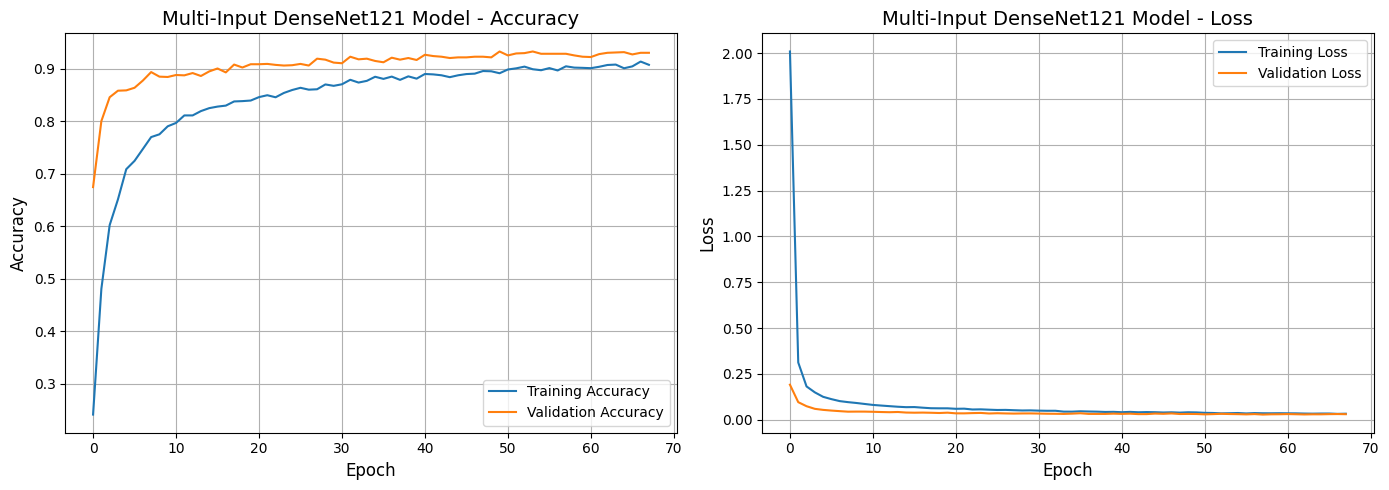

51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 281ms/step


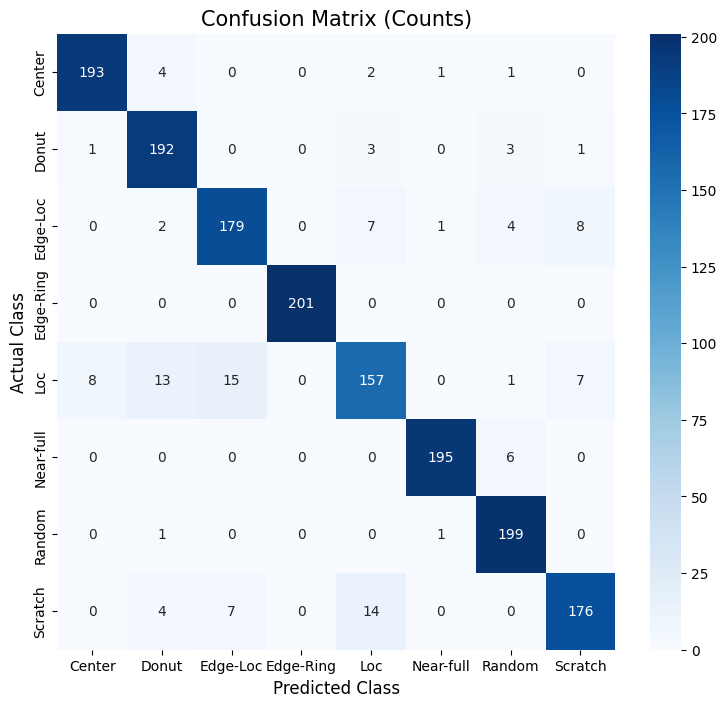

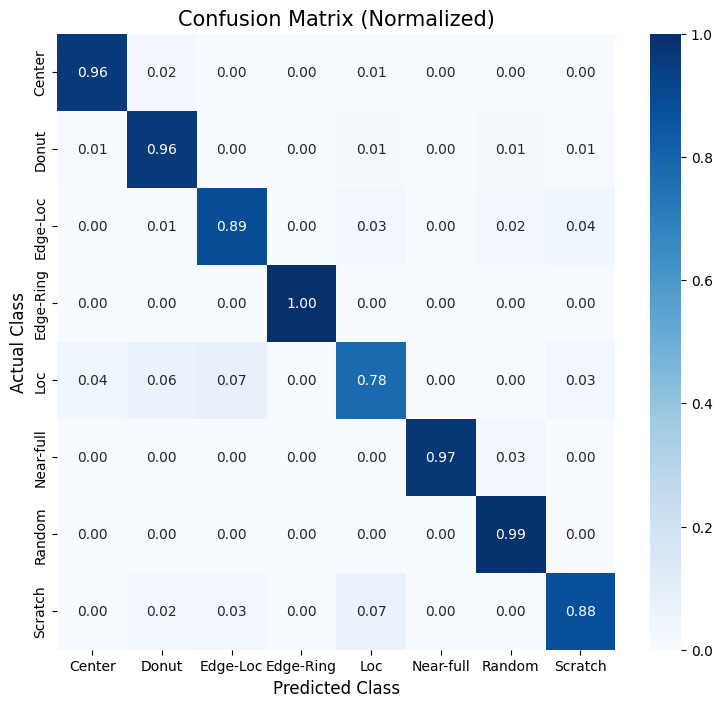

In [ ]:
# 훈련 모델 성능 시각화
plot_training_history(history_densenet121, "Multi-Input DenseNet121 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_densenet121.predict(X_test)

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

# **성능 비교 결과**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 이전에 훈련시킨 모델 변수들을 사용합니다.
models_to_evaluate = {
    "Simple NN": model_simple_nn,
    "DNN": model_dnn,
    "ANN": model_ann,
    "Custom CNN": model_cnn,
    "MobileNetV2": model_mobilenetv2,
    "MobileNetV3Small": model_mobilenetv3,
    "ResNet50": model_resnet50,
    "VGG16": model_vgg16,
    "InceptionV3": model_inceptionv3,
    "Xception": model_xception,
    "DenseNet121": model_densenet121
}

# 평가 결과를 저장할 리스트
results = []

# 원-핫 인코딩된 y_test를 다시 정수 라벨로 변환
y_test_integer_labels = np.argmax(y_test, axis=1)

# 성능 평가
for model_name, model in models_to_evaluate.items():
    print(f"Evaluating {model_name}...")

    # 예측을 수행할 때 4개의 입력을 담은 'X_test' 딕셔너리를 전달합니다.
    y_pred_probs = model.predict(X_test, verbose=0)

    # 예측된 확률에서 가장 높은 값의 인덱스를 찾아 최종 클래스로 변환
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    # 3. 평가 지표 계산
    accuracy = accuracy_score(y_test_integer_labels, y_pred_classes)
    precision = precision_score(y_test_integer_labels, y_pred_classes, average='weighted', zero_division=0)
    recall = recall_score(y_test_integer_labels, y_pred_classes, average='weighted', zero_division=0)
    f1 = f1_score(y_test_integer_labels, y_pred_classes, average='weighted', zero_division=0)

    # 4. 결과 저장
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# --- 5. 최종 결과를 DataFrame으로 변환하고 정렬 ---
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("\n\n--- 최종 모델 성능 비교표 (F1-Score 기준 정렬) ---")
display(results_df_sorted)

Evaluating Simple NN...
Evaluating DNN...
Evaluating ANN...
Evaluating Custom CNN...
Evaluating MobileNetV2...
Evaluating MobileNetV3Small...
Evaluating ResNet50...
Evaluating VGG16...
Evaluating InceptionV3...
Evaluating Xception...
Evaluating DenseNet121...


--- 최종 모델 성능 비교표 (F1-Score 기준 정렬) ---


,Model,Accuracy,Precision,Recall,F1-Score
0,ResNet50,0.930927,0.932439,0.930927,0.931208
1,MobileNetV3Small,0.932172,0.931706,0.932172,0.930964
2,MobileNetV2,0.929060,0.928458,0.929060,0.928339
3,DenseNet121,0.928438,0.928053,0.928438,0.927666
4,Xception,0.927816,0.927052,0.927816,0.927278
5,VGG16,0.927194,0.926962,0.927194,0.926114
6,InceptionV3,0.886745,0.888427,0.886745,0.885995
7,Custom CNN,0.815184,0.848906,0.815184,0.808193
8,ANN,0.125078,0.015644,0.125078,0.027810
9,Simple NN,0.125078,0.015644,0.125078,0.027810
